# Проект 12 спринта: предсказание вероятности клика AdTech платформы Advandex

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 13 июня 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/sprint_12_project_advandex
___

## Описание задачи

Построить модель бинарной классификации для AdTech‑платформы Advandex, которая предсказывает вероятность клика (CTR) на рекламное объявление, провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.

Некорректные прогнозы несут прямые финансовые риски для платформы: если модель систематически завышает CTR (например, предсказывает 20 % при реальных 5 %), это приведёт к перерасходу бюджета рекламодателей, потере их доверия и неэффективным победам в аукционах. Напротив, заниженные оценки (5 % вместо реальных 20 %) заставят платформу проигрывать аукционы за перспективные показы — и терять потенциальный доход.

Конечная цель — создать точную и достоверную модель, в которой предсказанный показатель CTR максимально близко отражает реальную вероятность клика: если модель выдаёт 20 %, то в среднем клик должен происходить в 20 случаях из 100. Такая калибровка критически важна для бизнес‑модели Advandex, поскольку достоверность предсказаний напрямую влияет на эффективность аукционов и финансовые результаты платформы.
___

## Выбор метрик

Для оценки модели в этом проекте будут использованы три ключевые метрики:

- **PR-AUC** — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы, но при этом оно критически важно для бизнеса. Поэтому метрика PR-AUC идеально подойдёт. Она игнорирует дисбаланс классов и позволяет оценить, насколько хорошо модель находит именно целевые действия — клики.
- **Log Loss** позволит оценить точность предсказанных вероятностей. Это важно, чтобы оптимизировать ставки на аукционах, где от достоверности вероятностей напрямую зависит эффективность расходов рекламодателей.
- **Оценка Бриера** измеряет и точность, и калибровку модели, то есть общее соответствие прогнозов реальным результатам. Для платформы это имеет прямое финансовое значение, так как ошибки в прогнозах приводят либо к переплатам, либо к упущенной выгоде.

При необходимости используйте дополнительные метрики. Они могут помочь в спорных ситуациях:

- Для детального анализа калибровки пригодятся метрики **ECE** и **MCE**. Они оценивают, насколько хорошо откалиброваны предсказанные вероятности по разным диапазонам.
- Вспомогательные метрики точности:
  - **Precision** — точность предсказания кликов.
  - **Recall** — полнота охвата реальных кликов.
  - **F1-score** — балансирует точность и полноту.
___


## Описание данных

#### Идентификаторы и временные метки:

- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

#### Характеристики рекламной площадки (Site):

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

#### Характеристики рекламируемого приложения (App):

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

#### Характеристики устройства и соединения пользователя:

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

#### Характеристики рекламного баннера и аукциона:

- `C1` — анонимизированный признак, характеризующий контекст показа;
- `banner_pos` — позиция баннера на веб-странице;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

#### Машинно-сгенерированные признаки (ML Features):

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

#### Целевая переменная:

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.
___


# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.
___

In [ ]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

# Предобрабока данных
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, VarianceThreshold, SequentialFeatureSelector, RFE

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import  LeaveOneOutEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report, precision_recall_curve

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import joblib
import os
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning) 

path = os.getcwd()
RANDOM_SEED = 555

In [2]:
# Подготавливаем функции визуализации данных

# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()

# phik heatmap
def phik_coolwarm_matrix(df, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()

# Функция вывода результата по обучению модели
def fit_results(fitted_model):
    # Записываем результаты SVM Linear модели
    model_means = {
        'pr_auc': fitted_model['test_average_precision'].mean().round(3),
        'precision': fitted_model['test_precision'].mean().round(3),
        'recall': fitted_model['test_recall'].mean().round(3),
        'f1': fitted_model['test_f1'].mean().round(3)
    } 

    print("Результаты модели на кросс-валидации (средние значения):")
    print("-" * 50)
    print(f"pr_auc: {model_means['pr_auc']:.3f}")
    print(f"precision:   {model_means['precision']:.3f}")
    print(f"recall: {model_means['recall']:.3f}")
    print(f"f1:   {model_means['f1']:.3f}")

    # Извлекаем стандартные отклонения метрик
    results_std = {
        "pr_auc": fitted_model["test_average_precision"].std(), 
        "precision": fitted_model["test_precision"].std(),
        "recall": fitted_model["test_recall"].std(), 
        "f1": fitted_model["test_f1"].std(),
    }

    print("Результаты модели на кросс-валидации (стандартные отклонения):")
    print("-" * 50)
    print(f"pr_auc: {results_std['pr_auc']:.3f}")
    print(f"precision:   {results_std['precision']:.3f}")
    print(f"recall: {results_std['recall']:.3f}")
    print(f"f1:   {results_std['f1']:.3f}")

# Функция сравнения моделей
def compare_model_results(model_means_base, model_means_est, model_est_name='Оцениваемая модель', model_base_name='Базовая модель'):
    print(f'Результаты модели {model_est_name} (средние значения):')
    print('-' * 50)
    print(f'PR-AUC: {model_means_est['pr_auc']:.3f}')
    print(f'precision:  {model_means_est['precision']:.3f}')
    print(f'recall:  {model_means_est['recall']:.3f}')
    print(f'F1:     {model_means_est['f1']:.3f}')

    # Сравнение с базовой моделью
    print('\nСравнение моделей:')
    print('-' * 50)
    print(f'{'Метрика':<12} {model_base_name:<12} {model_est_name:<12} {'Изменение':<10}')
    print('-' * 50)

    base_means = {
        'pr_auc': model_means_base['pr_auc'],
        'precision': model_means_base['precision'],
        'recall': model_means_base['recall'],
        'f1': model_means_base['pr_auc']
    }

    for metric in ['pr_auc', 'f1', 'precision', 'recall']:
        base_mean = model_means_base[metric]
        est_mean = model_means_est[metric]

        change = est_mean - base_mean
        change_str = f'{change:+.3f}'

        print(
            f'{metric.upper():<12} {base_mean:<12.3f} {est_mean:<12.3f} {change_str:<10}'
        )

In [3]:
# Загружаем датасет

df_init = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [4]:
# Знакомимся с данными
df_init.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [5]:
df_init.shape

(50000, 34)

In [6]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [7]:
# Создадим функцию оптимизации типов данных датафрейма
def optimize_dataframe(df):
    dataset_cols_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    dataset_cols_int = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

    for col in dataset_cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in dataset_cols_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

In [8]:
# Оптимизируем типы данных датафрейма и сохраним в новый рабочий датафрейм df_work. Первоначальный df_init оставляем для дальнейшей передачи в пром. 

df_work = optimize_dataframe(df_init)

## Комментарий по итогам подготовки среды и загрузки данных

- Подготовлено виртуальное окружение, состав библиотек проекта зафиксирован в файле `requirements.txt`.
- Импортированы все необходимые библиотеки и настроены системные параметры, а также параметры отображения графиков и датафреймов. Зафиксирована константа `RANDOM_SEED = 555`.
- Данные загружены успешно. Датасет содержит 34 атрибута и 50 000 записей.
- На основе начального датафрейма создан новый с оптимизированной структурой типов данных. Начальный датафрем оставлен для сравнения и отслеживания изменений по ходу проекта.
___

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

In [9]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

In [10]:
# Проверим на наличие явных дубликатов
df_work.duplicated().sum()

np.int64(0)

In [11]:
# Проверим на начиличие неявных дубликатов, исключив id показа
df_work.drop(columns=['click']).duplicated().sum()

np.int64(0)

#### Объём данных

- **Количество объектов (строк):** 50 000 (RangeIndex от 0 до 49 999).
- **Количество признаков (столбцов):** 34.
- **Пропуски:** Не обнаружены (во всех 34 колонках указано `50000 non-null`).
- **Дубликаты:** Не обнаружены.

#### Типы данных

В датасете представлены следующие основные типы данных:

- **Числовые:**
  - `float32` (7 колонок): `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`.
  - `float64` (1 колонка): `id`.
  - `int16` (7 колонок): `C1`, `C14`–`C17`, `C19`.
  - `int32` (2 колонки): `hour`, `C20`.
  - `int8` (6 колонок): `click`, `banner_pos`, `device_type`, `device_conn_type`, `C18`.

- **Категориальные / Строковые:**
  - `str` (11 колонок): `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_id`, `device_ip`, `device_model`, `ml_feature_2`, `ml_feature_7`.

#### Общее описание и контекст

Датасет описывает **показы рекламных баннеров** и содержит информацию, позволяющую связать контекст показа с поведением пользователя (кликом или его отсутствием).

**Что известно о рекламе:**
- **Площадка:** `site_id`, `site_domain`, `site_category` — где именно был показан баннер (сайт, его домен и тематика).
- **Продукт/Приложение:** `app_id`, `app_domain`, `app_category` — что рекламировалось (идентификатор, домен и категория приложения).
- **Позиция и контекст:** `banner_pos` (позиция на странице), `C1` (контекст показа), анонимизированные признаки `C14`–`C21` (дополнительные параметры аукциона/баннера).

**Что известно о пользователе:**
- **Устройство:** `device_model`, `device_type` (смартфон, ПК и т. д.), `device_conn_type` (тип соединения: Wi-Fi, 3G и др.).
- **Идентификаторы:** `device_id`, `device_ip` — для отслеживания конкретного устройства/пользователя.

**Целевая переменная:**
- `click` (тип `int8`) — бинарный признак, указывающий, был ли совершён клик (1 — клик был, 0 — не было). Это наша **целевая метка** для задачи бинарной классификации.

**Дополнительные признаки:**
- **Машинно-сгенерированные (`ml_feature_*`):** Представляют собой результат предварительной обработки. Включают как числовые (вероятно, агрегированные статистики), так и категориальные признаки.

**Краткий вывод:**  
Датасет сбалансирован по полноте (нет пропусков), не содержит дубликатов, содержит информацию как о рекламе, так и о пользователе, и готов к исследовательскому анализу и дальнейшей предобработке.
___


#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

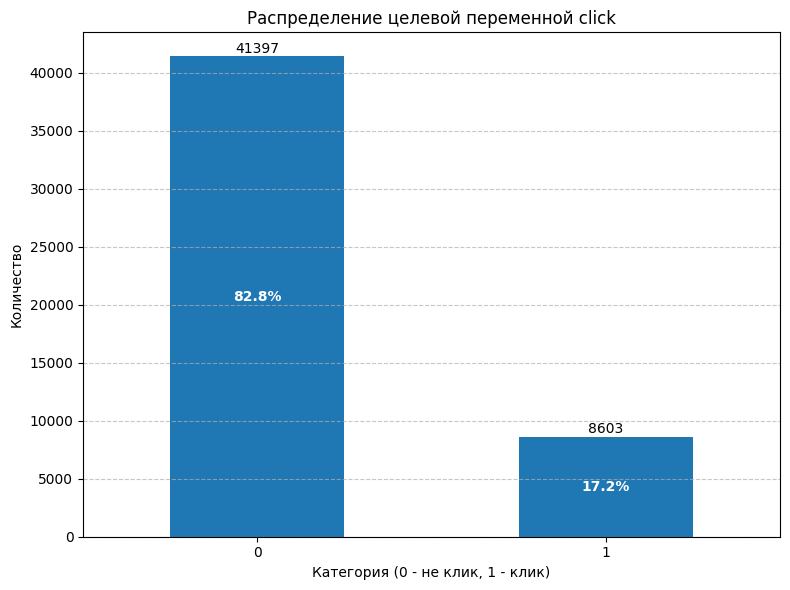

In [12]:
plot_bar_chart(data=df_work['click'], figsize=(8, 6), xlabel='Категория (0 - не клик, 1 - клик)', ylabel='Количество', title='Распределение целевой переменной click')

#### Целевая переменная `click`

1. **Распределение классов**  
   Целевая переменная `click` имеет два значения:
   - `0` (не клик) — **41 397** записей (82.8%);
   - `1` (клик) — **8 603** записи (17.2%).

2. **Наличие дисбаланса**  
   В датасете **явно выражен дисбаланс классов**.  
   Класс «не клик» (`0`) значительно преобладает над классом «клик» (`1`) в соотношении примерно **5 к 1**.  

3. **Выбор метрик**  
   Дисбаланс классов обосновывает использование в качестве основных метрик модели:
- **PR-AUC** (Precision-Recall AUC) - особенно информативен при сильном дисбалансе.
- **Precision (точность)** — доля верно предсказанных кликов среди всех предсказаний «клик».
- **Recall (полнота)** — доля реальных кликов, которые модель смогла найти.
- **F1-score** — гармоническое среднее между Precision и Recall (хорошо подходит для несбалансированных данных).
___


#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

In [13]:
df_work.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146790,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319133,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [14]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

In [15]:
# Напишем простую функцию удаления ненужных колонок
def drop_unneccesary_columns(df, cols_2_drop):
    return df.drop(columns=cols_2_drop)

In [16]:
# Сдлаем первое разделение на категориальные и числовые характеристики
float_cols = df_work.select_dtypes(include=['float64', 'float32']).columns.tolist() 
int_cols = df_work.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns.tolist() + ['hour', 'C20'] # по какой то принине не видит тип int32. Добавляем в ручную. 
cat_cols = df_work.select_dtypes(include=['str']).columns.tolist()

len(float_cols + int_cols + cat_cols) # Проверим, что ничего не потеряли. Всего 34 признака, включая целевую переменную.

34

In [17]:
# Посмотрим на кагориальные признаки с типом str
df_work[cat_cols].describe()

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,ml_feature_2,ml_feature_7
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,1160,1013,18,976,67,22,8580,41455,2521,5,3
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,a99f214a,6b9769f2,8a4875bd,E,Y
freq,18011,18645,20457,31989,33763,32388,41213,265,3007,10112,17081


In [18]:
# Посомтрим на целочисленные признаки как на категориальные

# Час показа баннера показан в формате даты. Приведем именно часу, как к категории времени суток.
df_work['hour'] = df_work['hour'] % 100

df_work[int_cols].astype('str').describe()

,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,2,7,7,4,4,1497,8,9,387,4,64,59,2,24,149
top,0,1005,0,1,0,4687,320,50,1722,0,35,23,0,13,-1
freq,41397,45835,35883,46031,43021,1200,46787,47287,5637,21074,14964,10919,25098,3013,23443


In [19]:
# Посмотрим на признаки с плавающей точкой
df_work[float_cols].describe()

,id,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


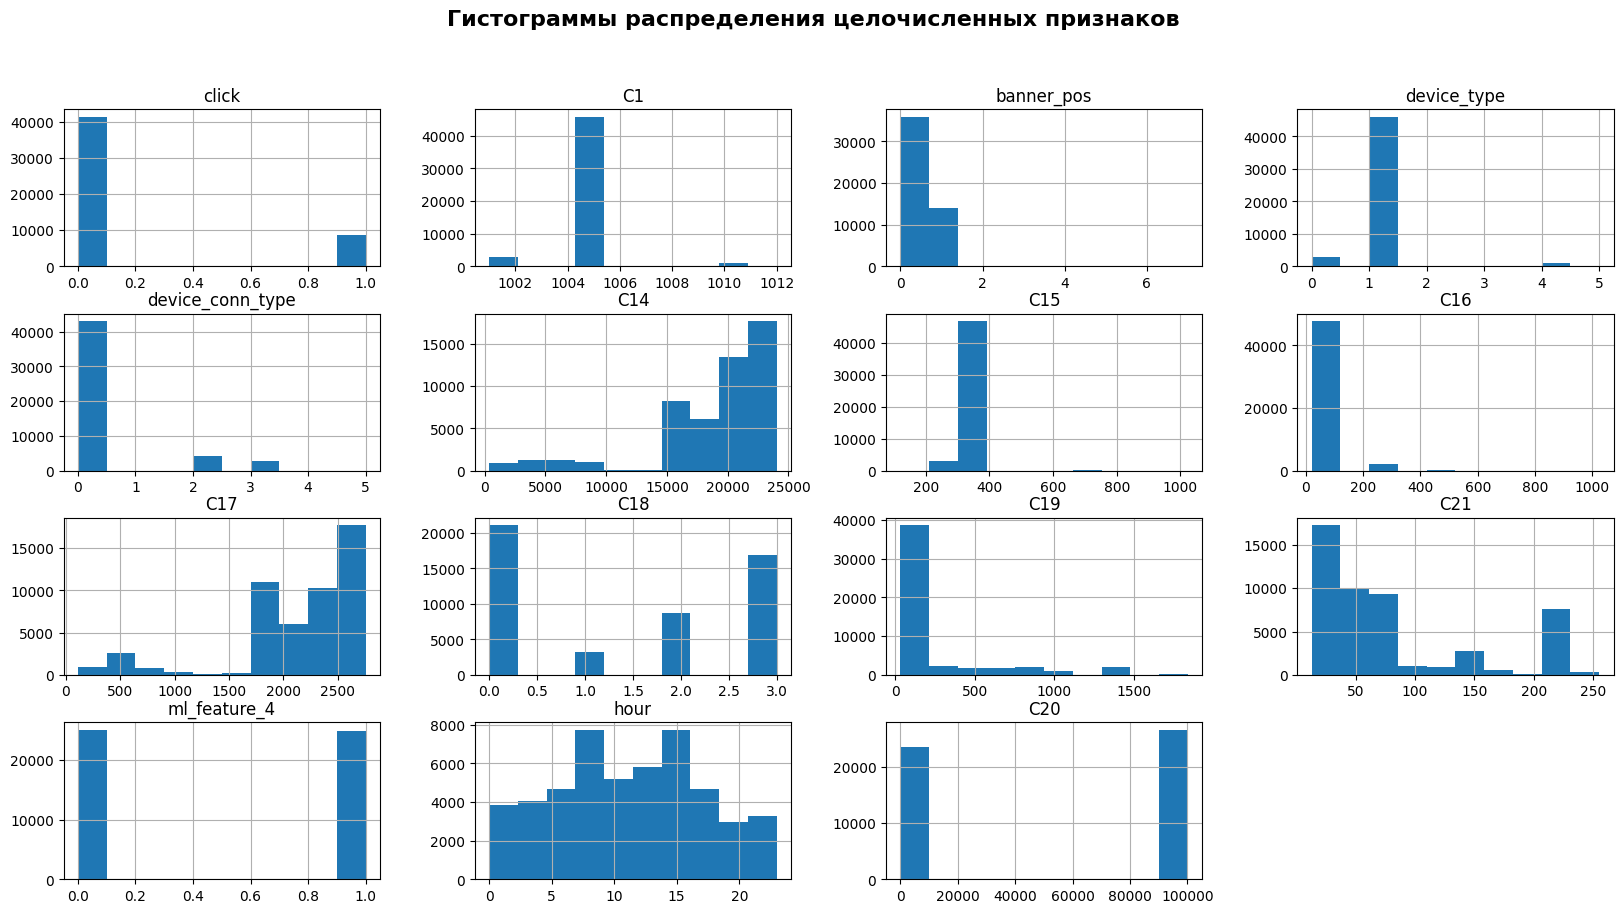

In [20]:
# Посмотрим на целочисленные признаки них на графиках. 
df_work[int_cols].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения целочисленных признаков', fontsize=16, fontweight='bold')
plt.show()

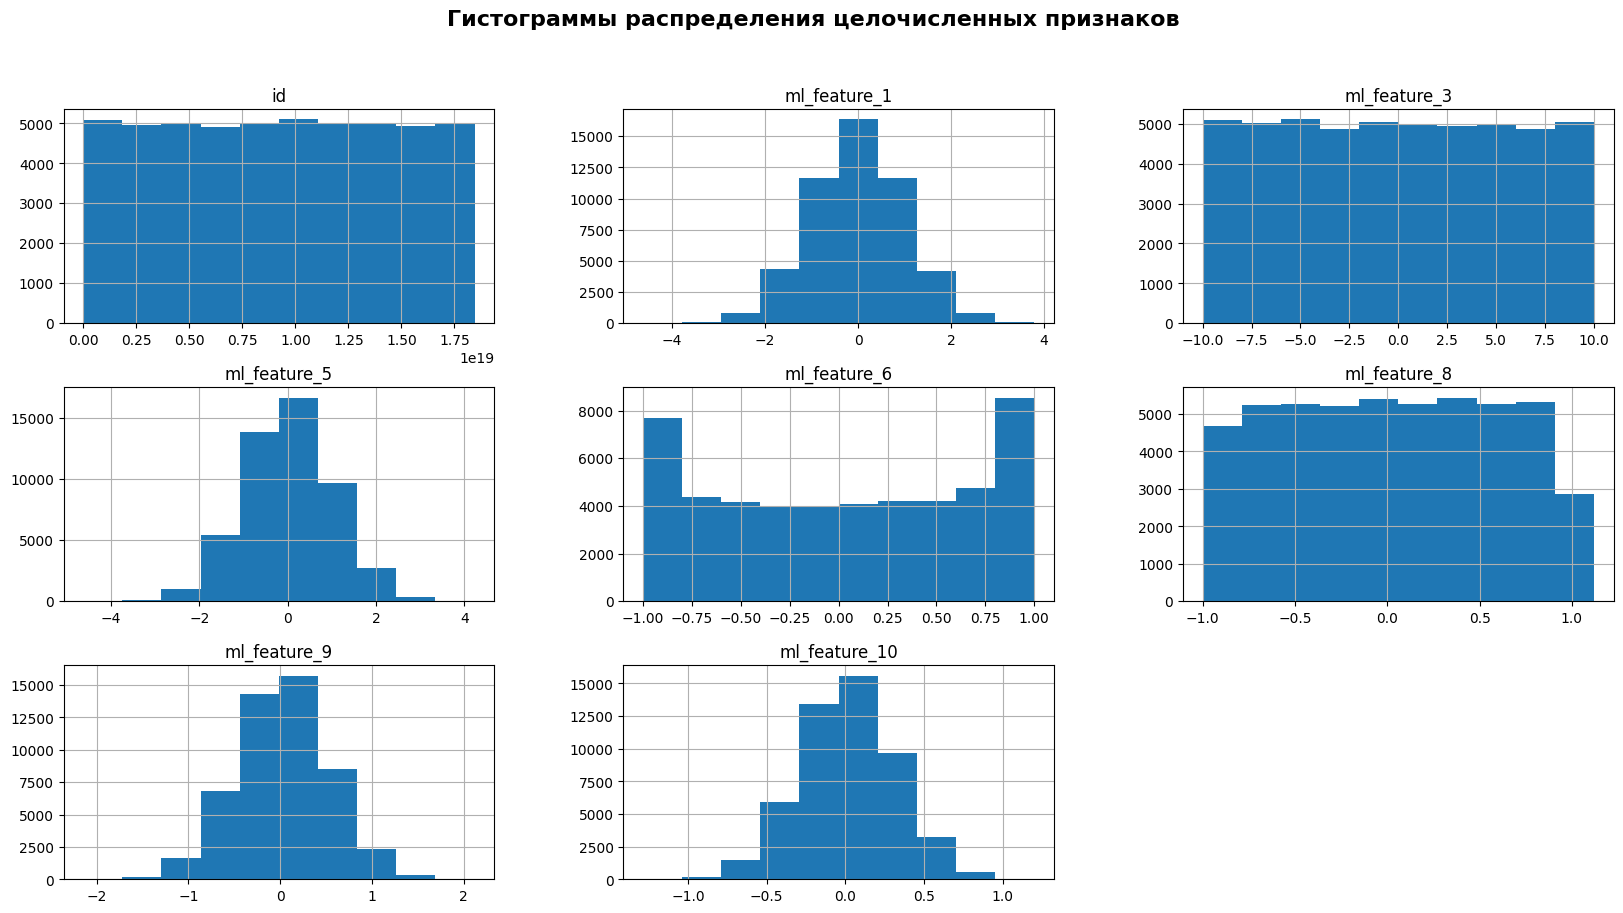

In [21]:
# Посмотрим на признаки с плавающей точкой на графиках. 
df_work[float_cols].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения целочисленных признаков', fontsize=16, fontweight='bold')
plt.show()

In [22]:
# Классифицируем признаки: целевая переменная и колонки, которые можно удалить
target = ['click'] # Целевая переменная
columns_to_drop = ['id', 'device_type', 'device_id', 'device_ip', 'device_model', 'device_conn_type'] # Есть сомнение, что идентификатор показа и характеристики устройства и соединения пользователя могут влиять на принятие им решения о клике
cat_features = [item for item in int_cols + cat_cols if item not in target + columns_to_drop] # К категориальным принакам относим все текстовые и целовисленные переменные
num_features = [item for item in float_cols if item not in target + columns_to_drop] # К числовым признакам относим числа с плавающей точкой

len(target + columns_to_drop + cat_features + num_features)

34

In [23]:
# Удалим ненужные колонки
df_work = optimize_dataframe(drop_unneccesary_columns(df_work, columns_to_drop))
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   click          50000 non-null  int8   
 1   hour           50000 non-null  int32  
 2   C1             50000 non-null  int16  
 3   banner_pos     50000 non-null  int8   
 4   site_id        50000 non-null  str    
 5   site_domain    50000 non-null  str    
 6   site_category  50000 non-null  str    
 7   app_id         50000 non-null  str    
 8   app_domain     50000 non-null  str    
 9   app_category   50000 non-null  str    
 10  C14            50000 non-null  int16  
 11  C15            50000 non-null  int16  
 12  C16            50000 non-null  int16  
 13  C17            50000 non-null  int16  
 14  C18            50000 non-null  int8   
 15  C19            50000 non-null  int16  
 16  C20            50000 non-null  int32  
 17  C21            50000 non-null  int16  
 18  ml_feature_1   50

#### Выводы по анализу признаков

В датасете 34 атрибута. Из них 1 целевая переменная `click`.

Принято решение **удалить как несущественные** идентификаторы показа баннера, а также признаки описывающие устройство пользователя:
- `id` - уникальный идентификатор записи о показе баннера;
- `device_id` - идентификатор браузера или устройства;
- `device_ip` - IP-адрес устройства;
- `device_model` - модель устройства;
- `device_type` - тип устройства пользователя;
- `device_conn_type` - тип сетевого соединения устройства
Всё это фоновые признаки, которые не оказывают влияния на принятие пользователем решения о клике.

К **категориальным признакам** относятся все признаки типа 'str' и целочисленные призаки датасета. Целовисленные признаки в описании к задаче даны как *аномизированные признаки, характеризующие контекст показа*, они содержат довольно мало уникальных значений (не более 70 при 50 тыс. записей в датасете). То есть можно сделать вывод о том, что они скорее несут цифровое обозначение некой категории, возможно даже порядковый признак, но не числовую характеристику. Префикс `C` часто используют для обозначение категориальных пеерменных. Исключение по числу уникальных значентий составляют `C14` - 1497, `C17` - 387 и `C20` - 149. Но характер их распределения (смещенный влево), нетипичный для числовых признаков, и то, что в описании к задаче они даны в одной группе без разделения, также говорит в пользу того, что это скорее не числовые характеристики, а коды обозначающие некоторую характеристику.
Признак `hour`, имевший формат YYMMDDHH приведен к часу HH, как характеристики времени суток, из него исключены данные о дате YYMMDD.

В **числовым признакам** были отнесены все колонки с типом 'float'. Имеют распределение похожее на нормальное (`ml_featue_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10`), равномерное распределение (`ml_feature_3`, `ml_feature_8`) и распределение с двумя вершинами по краям у `ml_feature_6`.

Итого в датасете остается **27 признаков и одна целевая переменная**.

___

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [24]:
df_work.isna().sum().sum()

np.int64(0)

In [25]:
df_work.isnull().sum().sum()

np.int64(0)

#### Выводы по итогам анализа пропущенных значений

В датасете отсутствуют. В дальнейшем при создании пайплайна для промышленной обработки пропусков `SimpleImputer` будем придерживаться для категориальных признаков рекомендованной в инструкции методики заполнения через **моду** или новой категорией **'unknown'**. Для числовых признаков выбор будет между медианой и средним значением. Рекомендации к выбору заполнения пропусков в этих двух классах переменных будут приняты после анализа распределений и выбросов.
___

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

In [26]:
df_work[cat_features].head()

,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7
0,1005,1,17614,320,50,1993,2,1063,33,0,0,-1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,A,Z
1,1005,0,15701,320,50,1722,0,35,79,1,0,-1,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,C,X
2,1005,0,17914,320,50,2043,2,39,32,0,0,100084,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,D,Y
3,1005,0,21611,320,50,2480,3,297,61,1,0,100111,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,A,Y
4,1005,0,15702,320,50,1722,0,35,79,1,0,100084,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,A,X


In [27]:
df_work[cat_features].astype('str').describe()

,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,7,7,1497,8,9,387,4,64,59,2,24,149,1160,1013,18,976,67,22,5,3
top,1005,0,4687,320,50,1722,0,35,23,0,13,-1,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,E,Y
freq,45835,35883,1200,46787,47287,5637,21074,14964,10919,25098,3013,23443,18011,18645,20457,31989,33763,32388,10112,17081


In [28]:
# Проверяем уникальные значения в столбцах
for column in cat_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_work[column].sort_values().unique())
    print('Число уникальных значений:', df_work[column].sort_values().nunique())
    print()

Уникальные значения в столбце C1:
[1001 1002 1005 1007 1008 1010 1012]
Число уникальных значений: 7

Уникальные значения в столбце banner_pos:
[0 1 2 3 4 5 7]
Число уникальных значений: 7

Уникальные значения в столбце C14:
[  375   377   380 ... 24041 24042 24043]
Число уникальных значений: 1497

Уникальные значения в столбце C15:
[ 120  216  300  320  480  728  768 1024]
Число уникальных значений: 8

Уникальные значения в столбце C16:
[  20   36   50   90  250  320  480  768 1024]
Число уникальных значений: 9

Уникальные значения в столбце C17:
[ 112  122  153  178  196  394  423  479  544  547  549  550  571  572
  576  613  686  761  768  827  863  898  901  906  937 1008 1076 1092
 1160 1161 1174 1248 1255 1272 1401 1426 1447 1507 1526 1528 1637 1685
 1694 1698 1702 1722 1740 1741 1752 1769 1780 1784 1800 1809 1821 1823
 1835 1863 1872 1873 1882 1884 1887 1895 1899 1903 1921 1926 1932 1934
 1939 1946 1955 1960 1965 1972 1973 1974 1991 1993 1994 1996 2009 2016
 2036 2039 2043 2060 

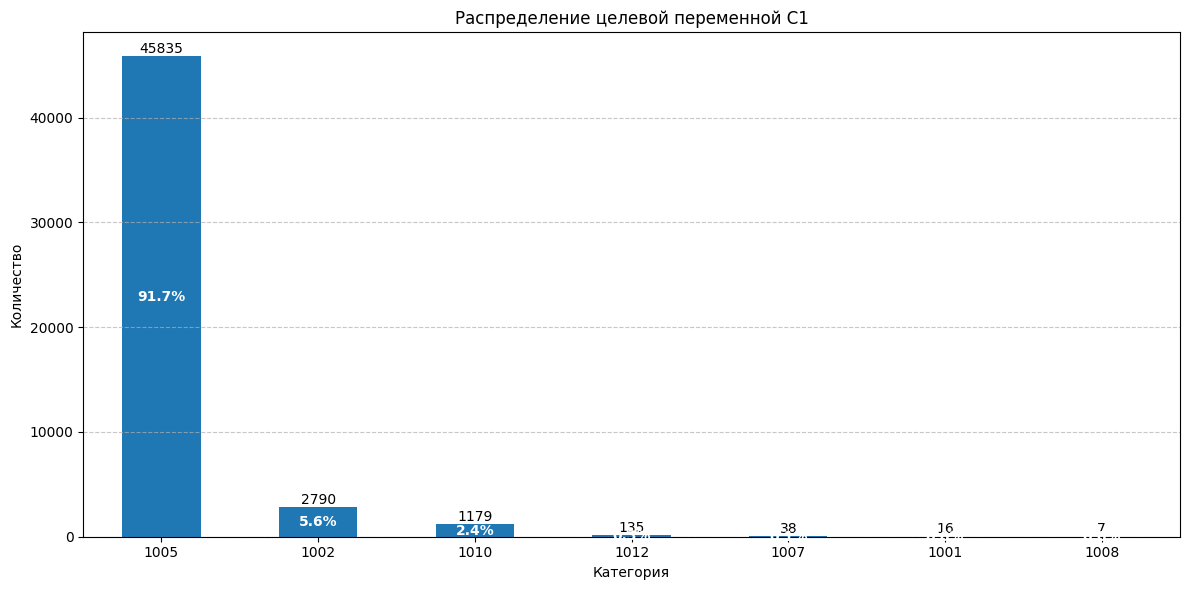

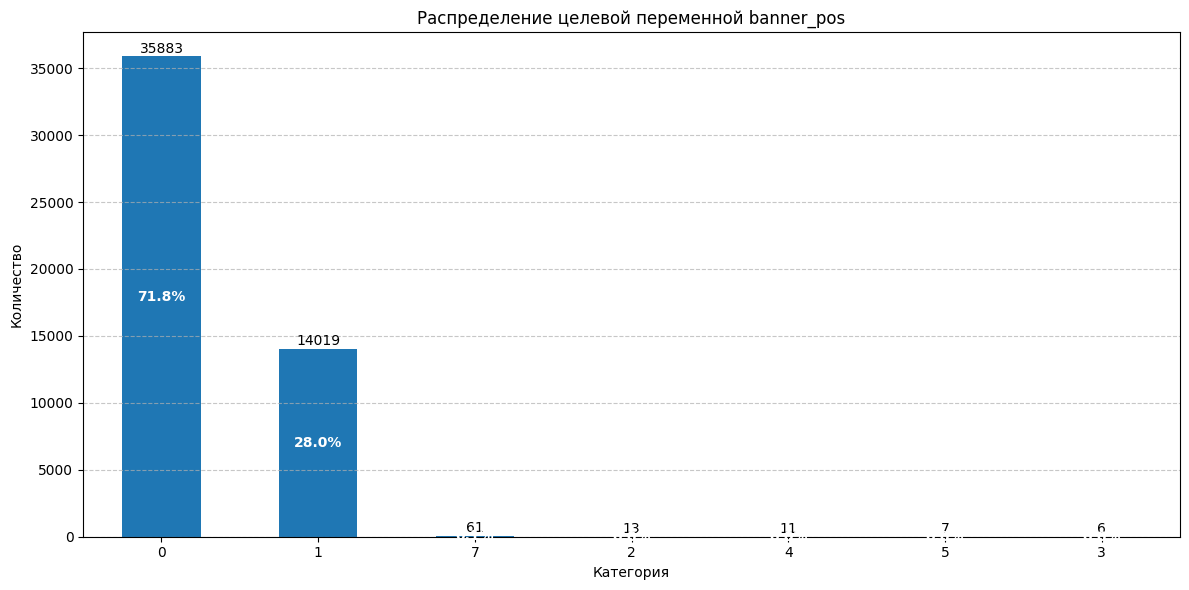

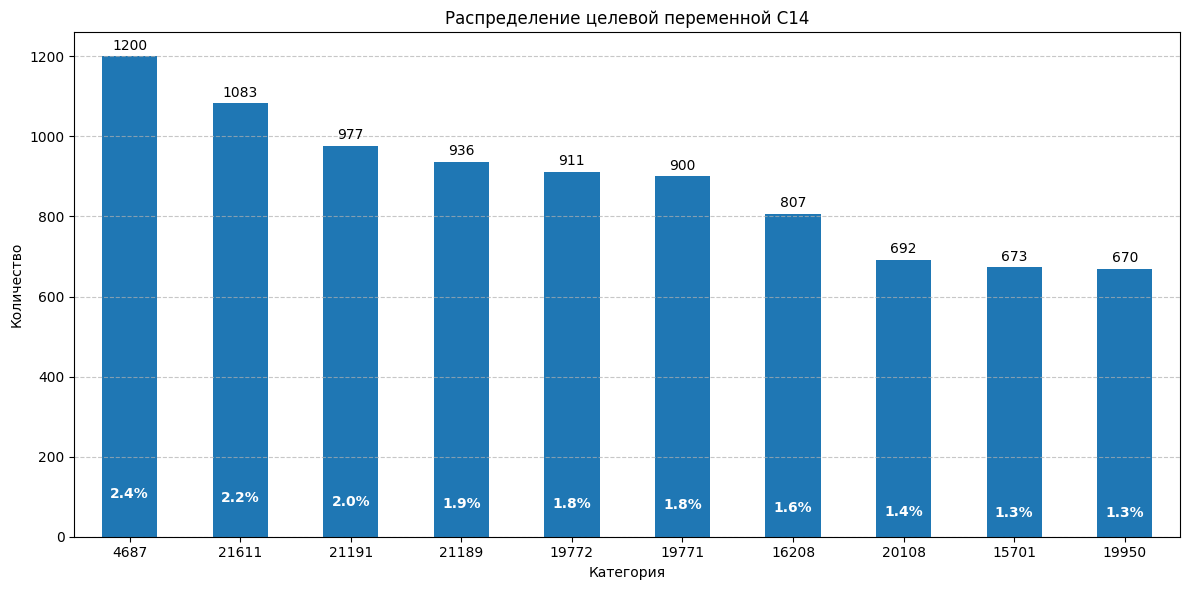

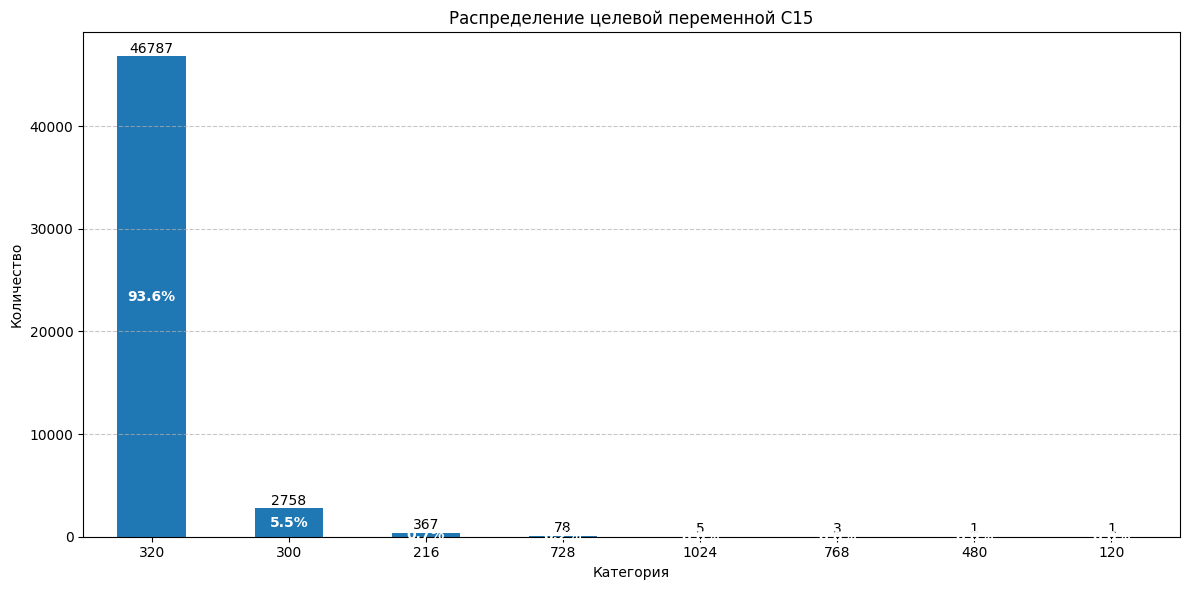

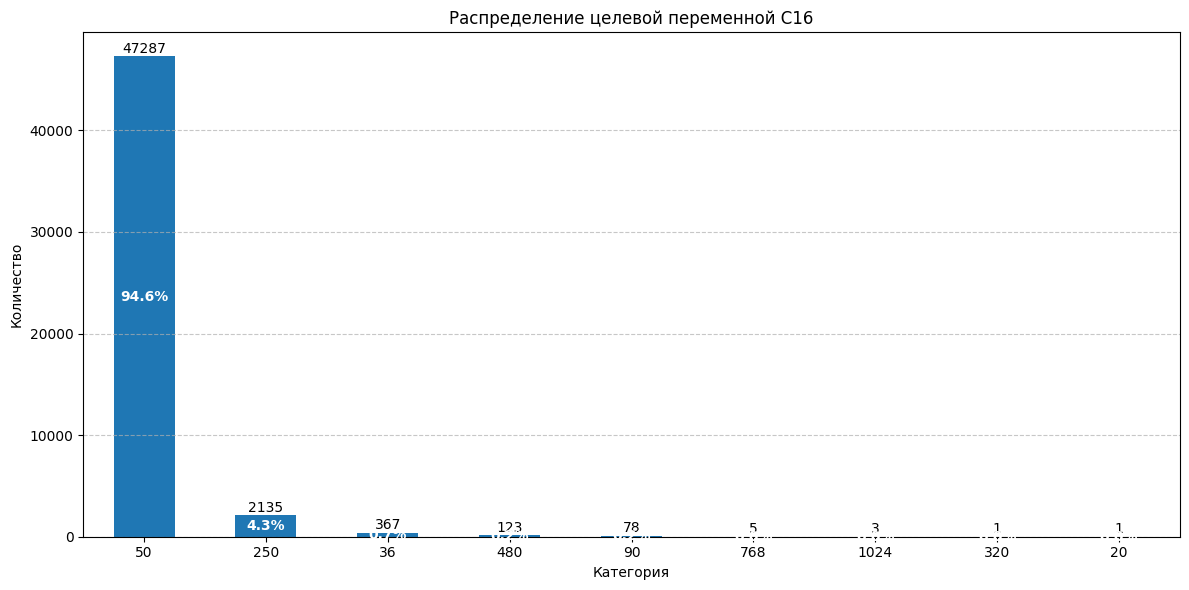

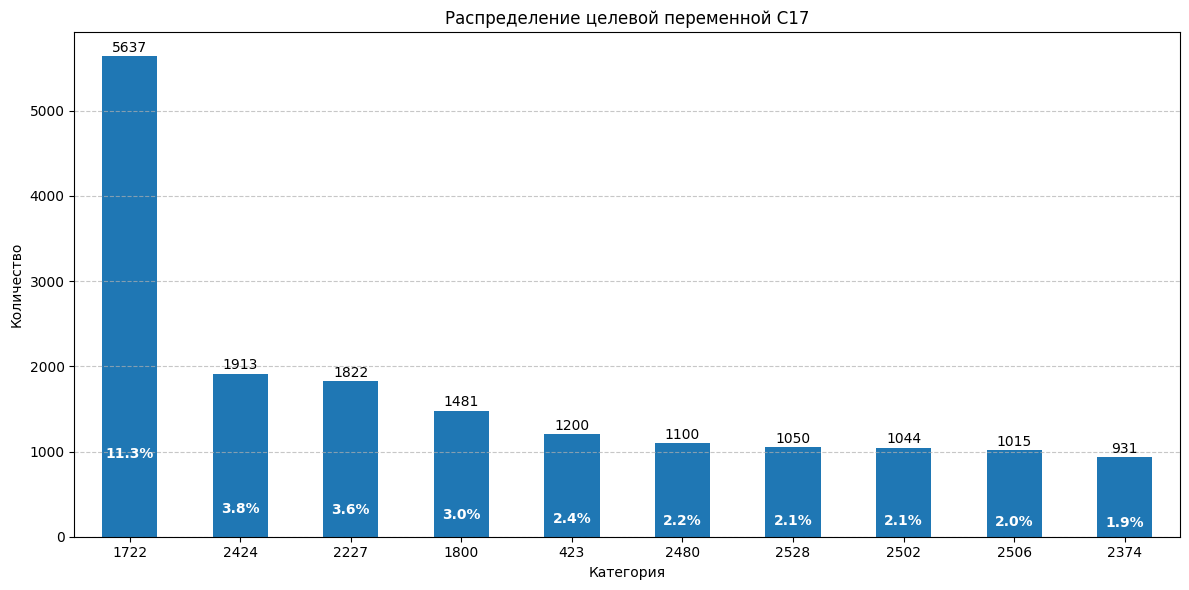

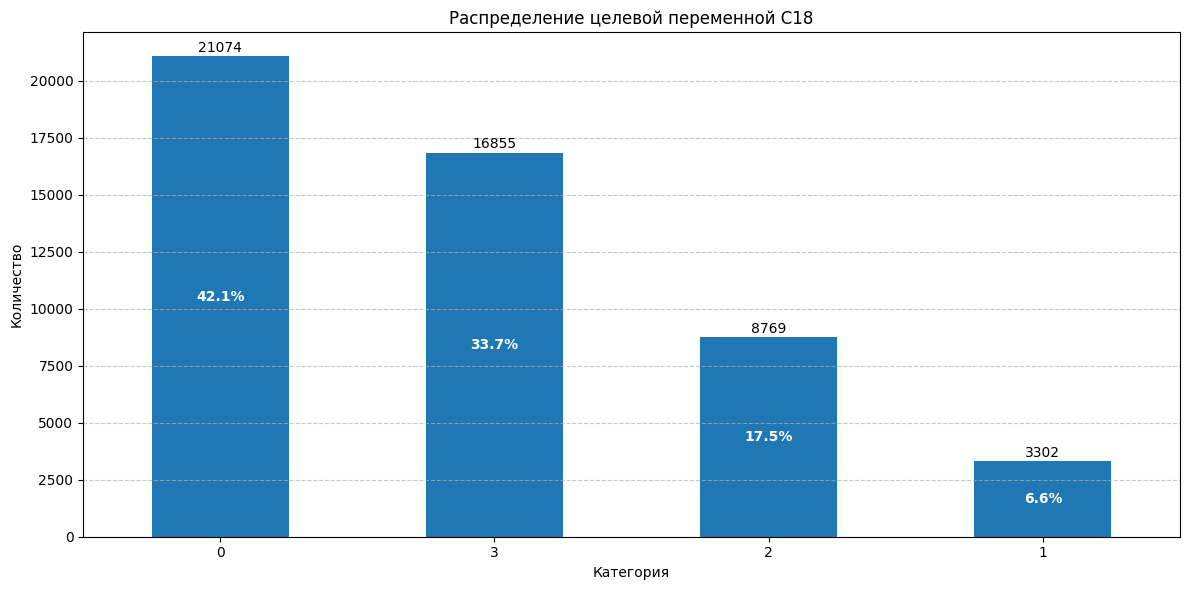

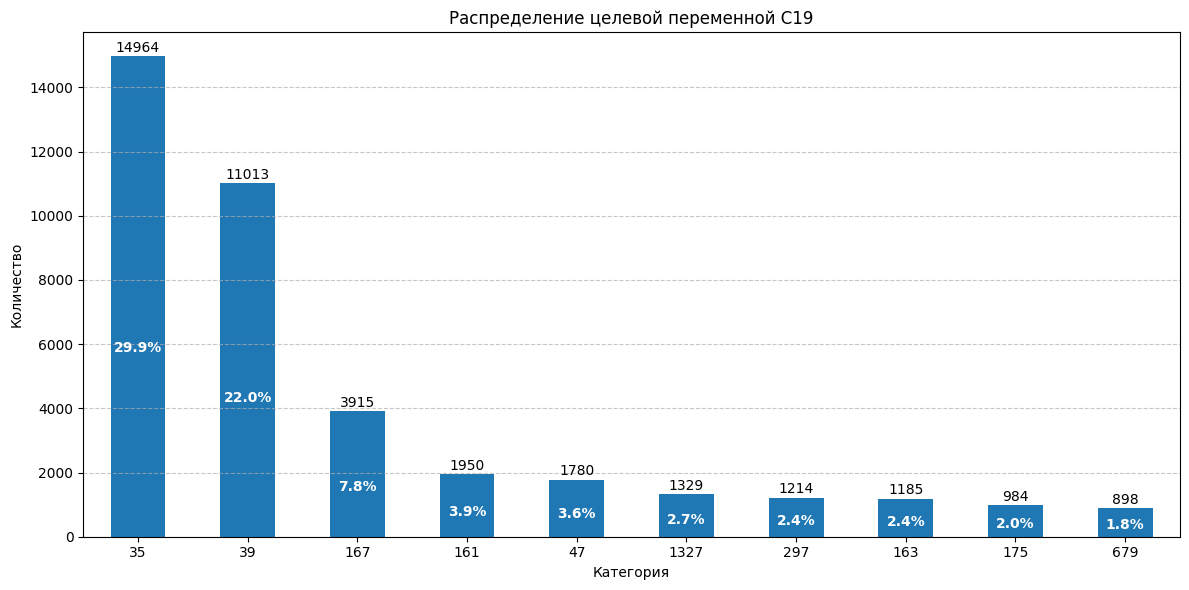

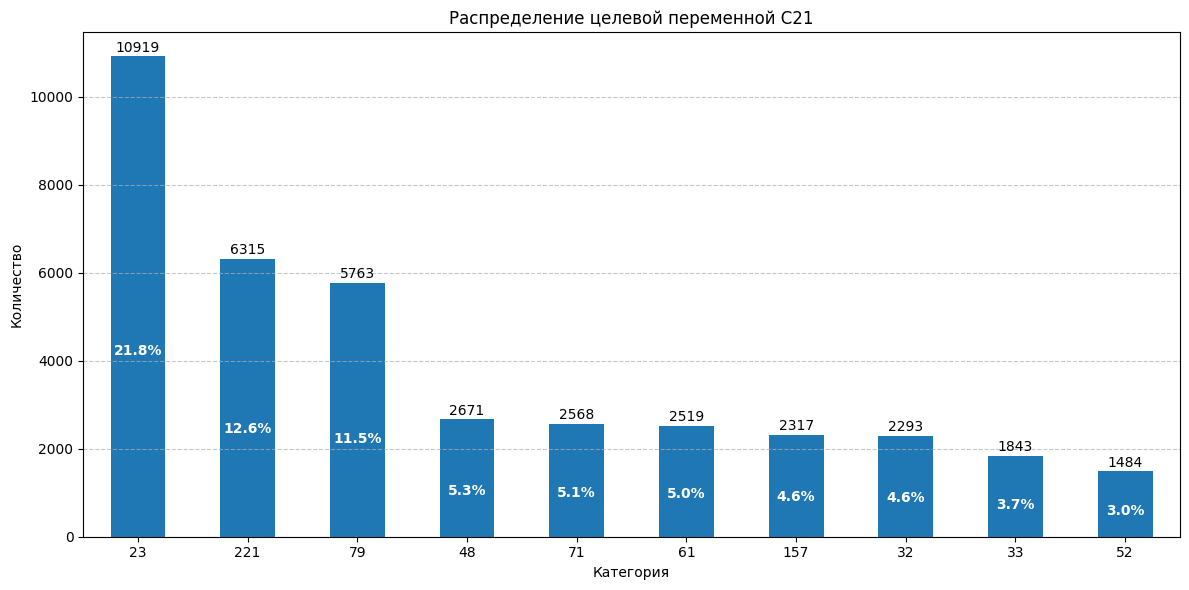

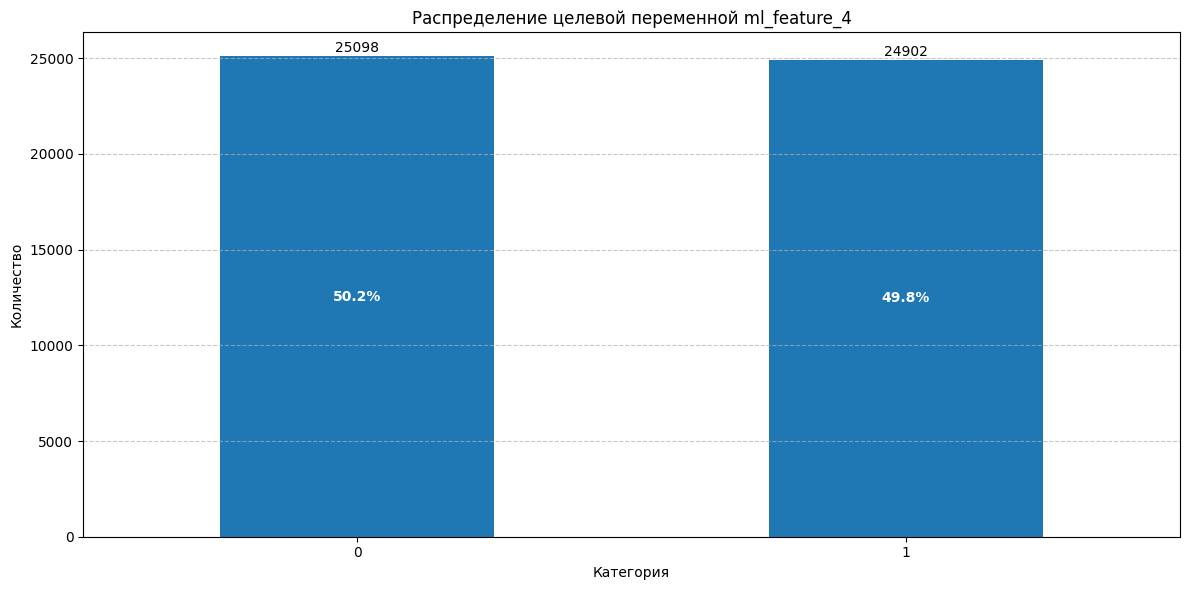

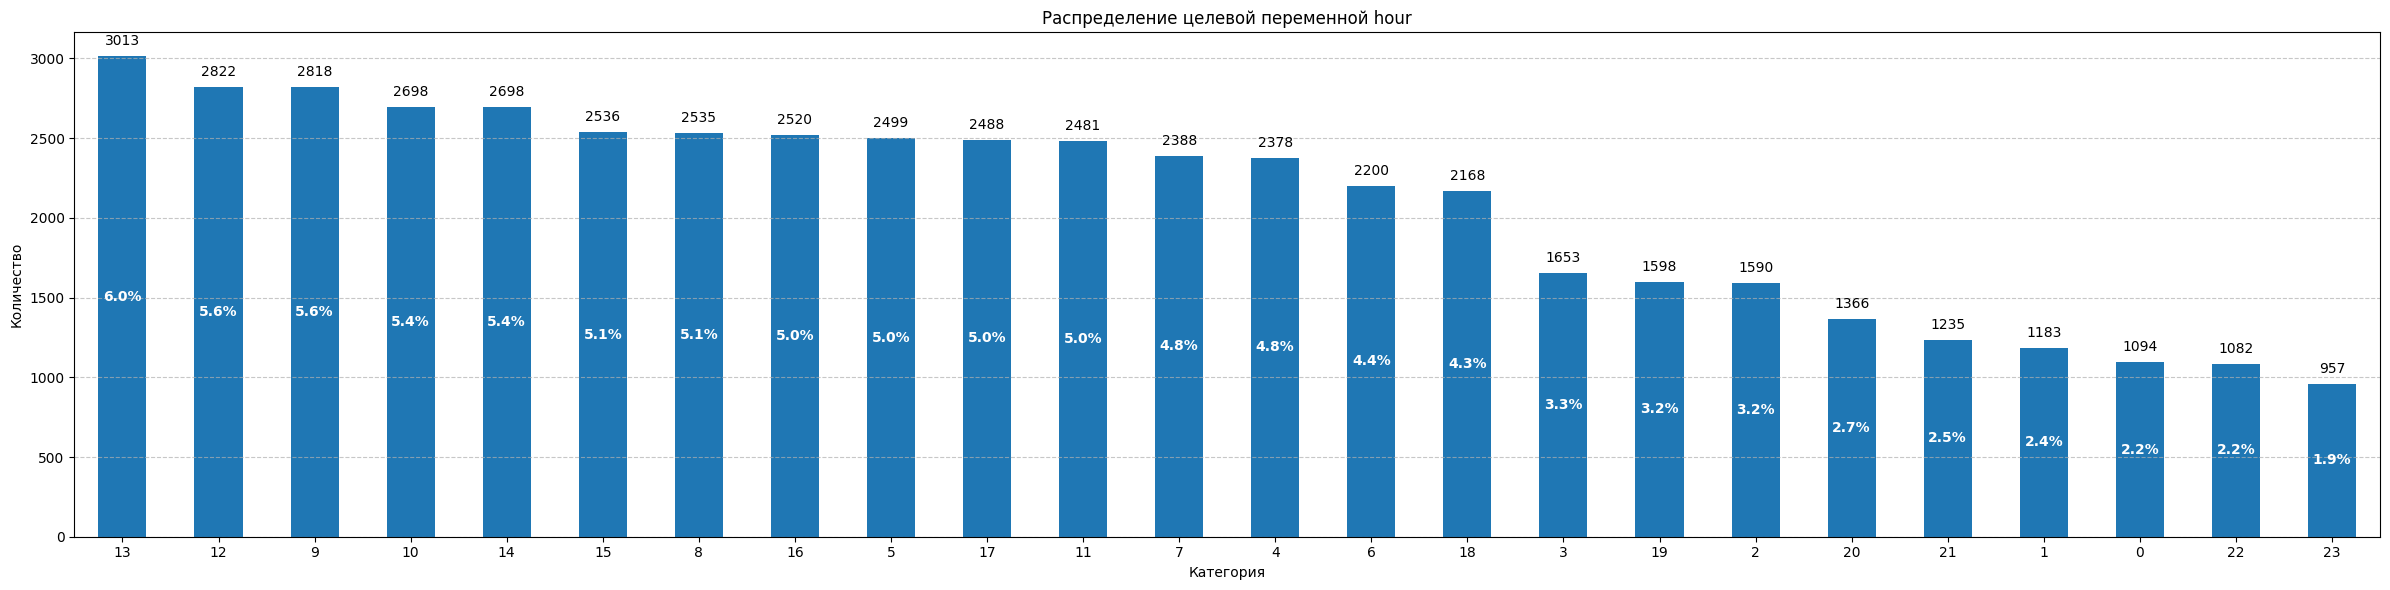

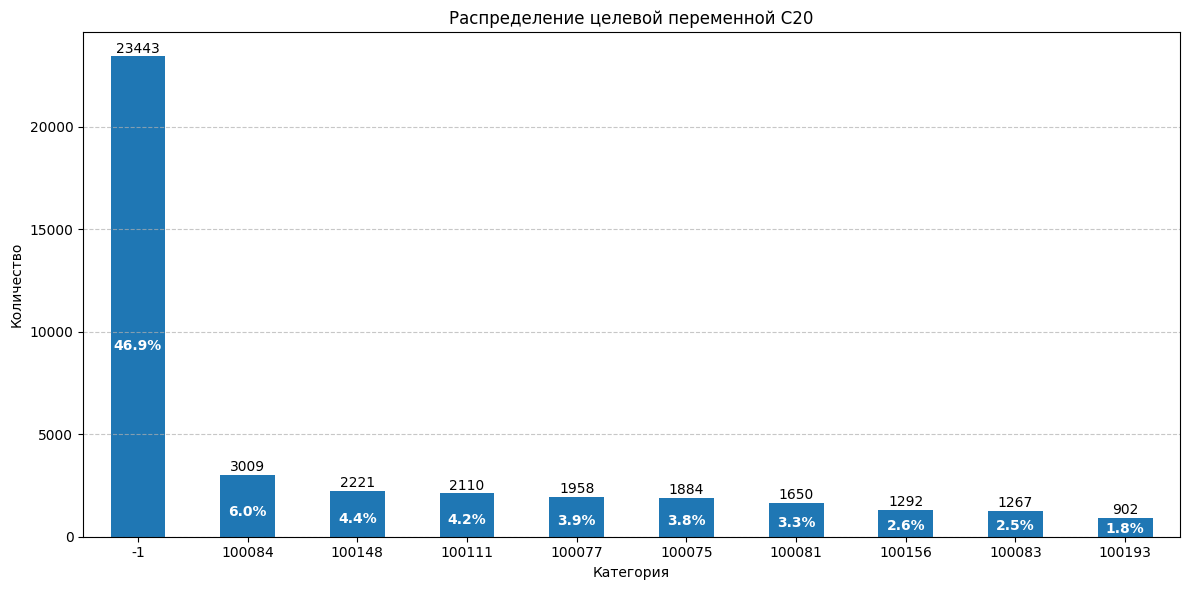

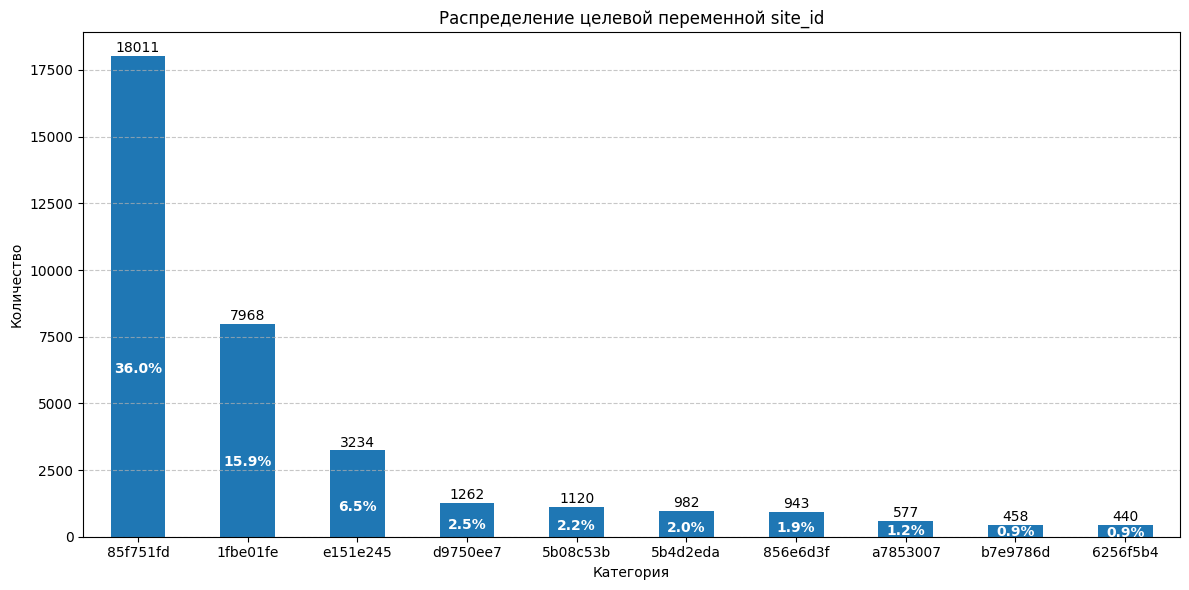

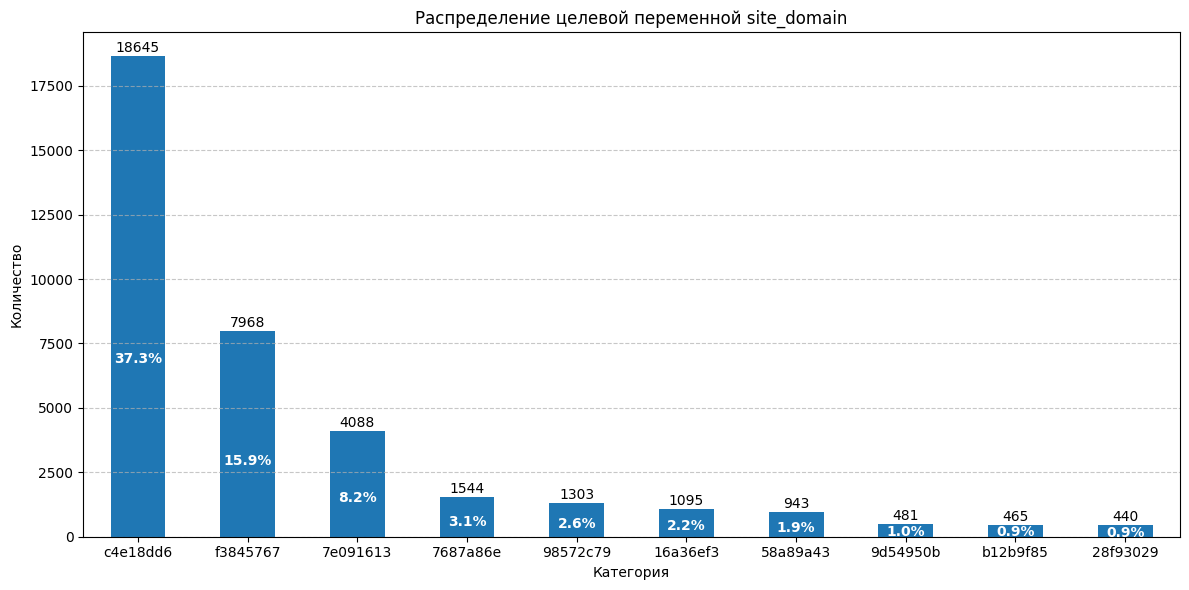

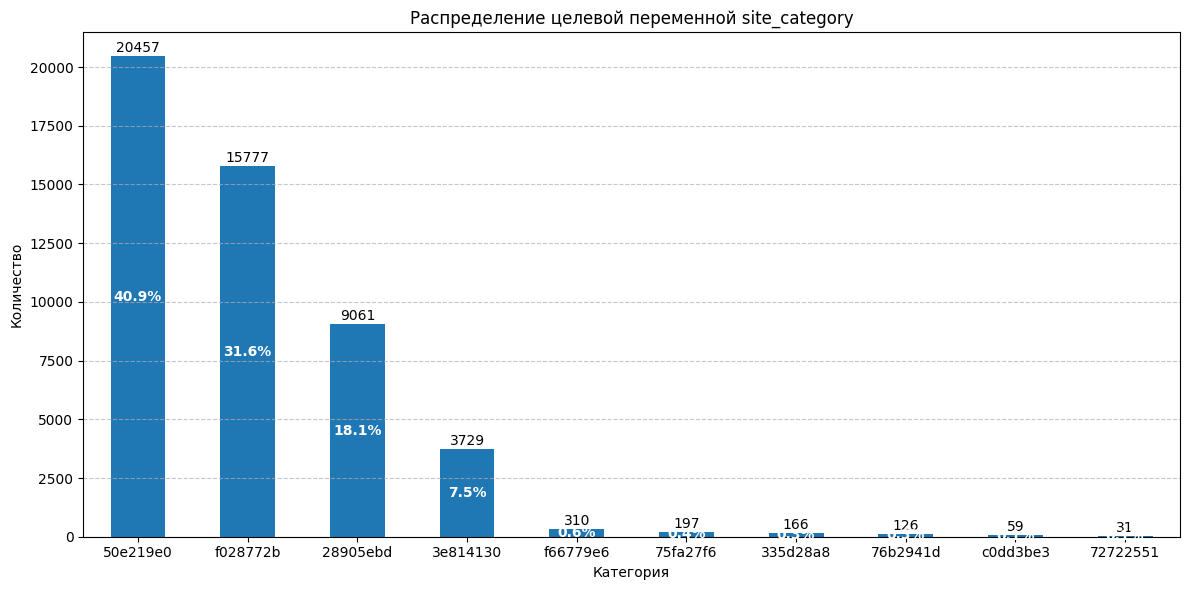

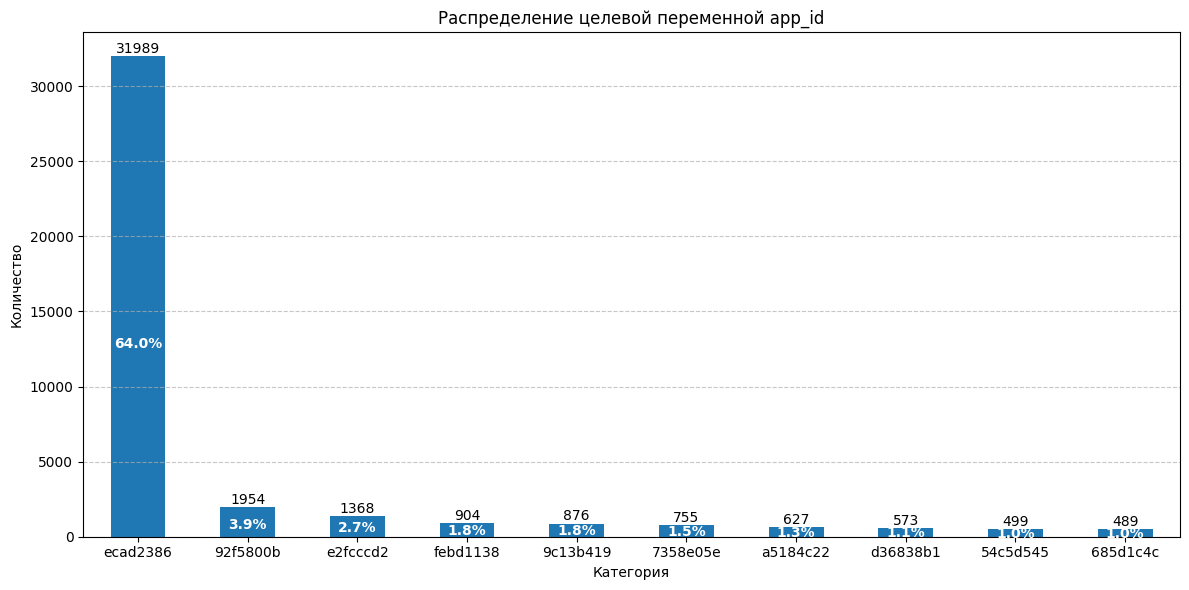

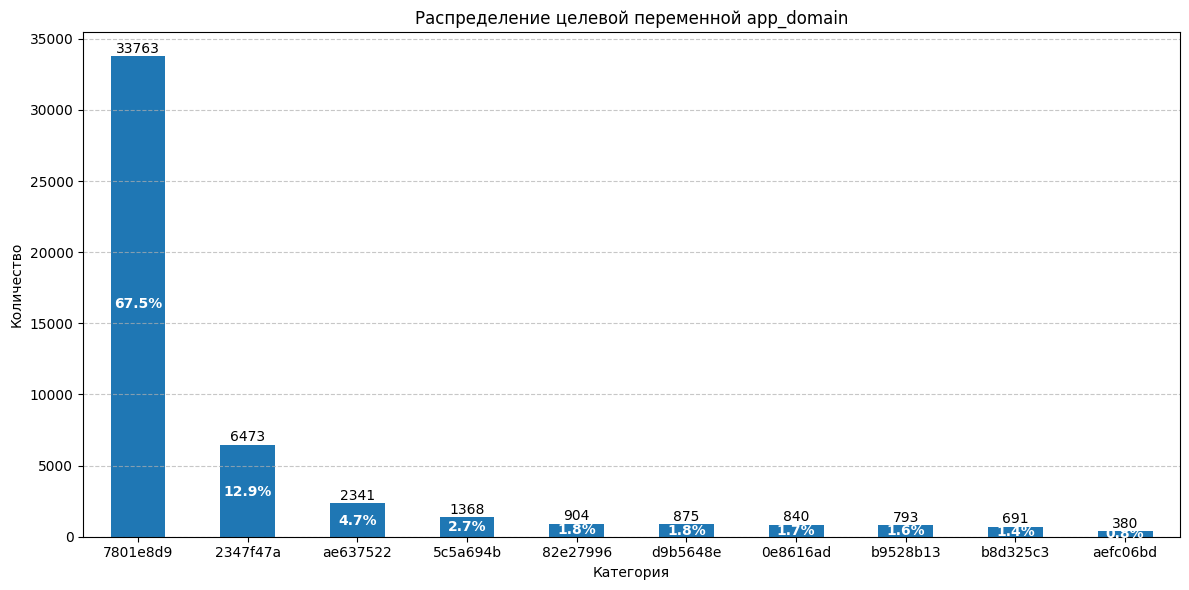

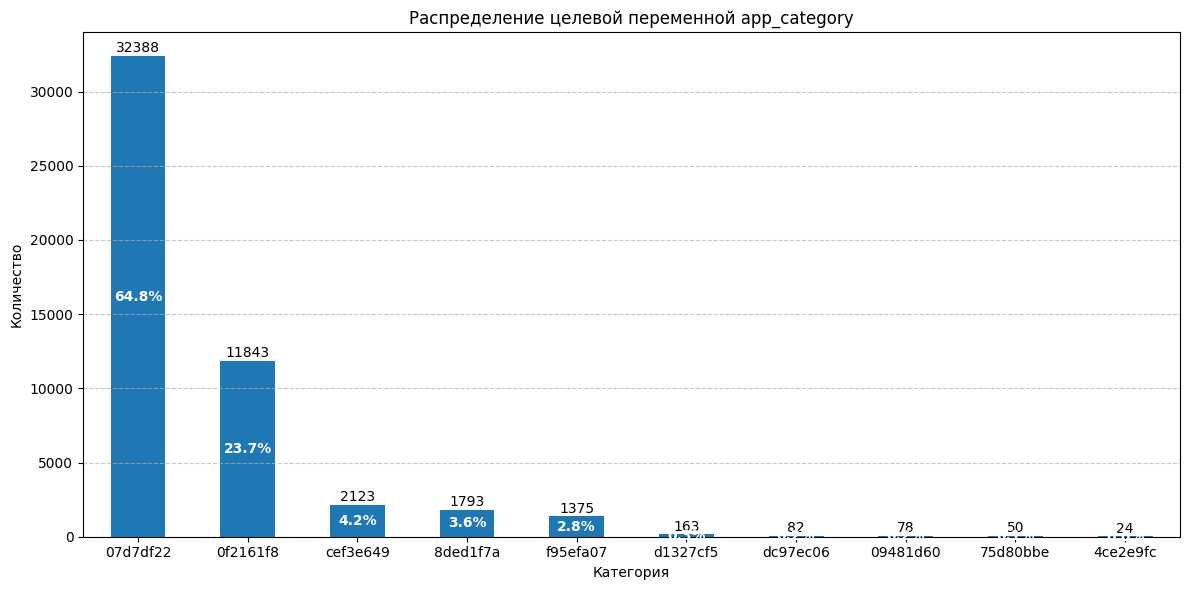

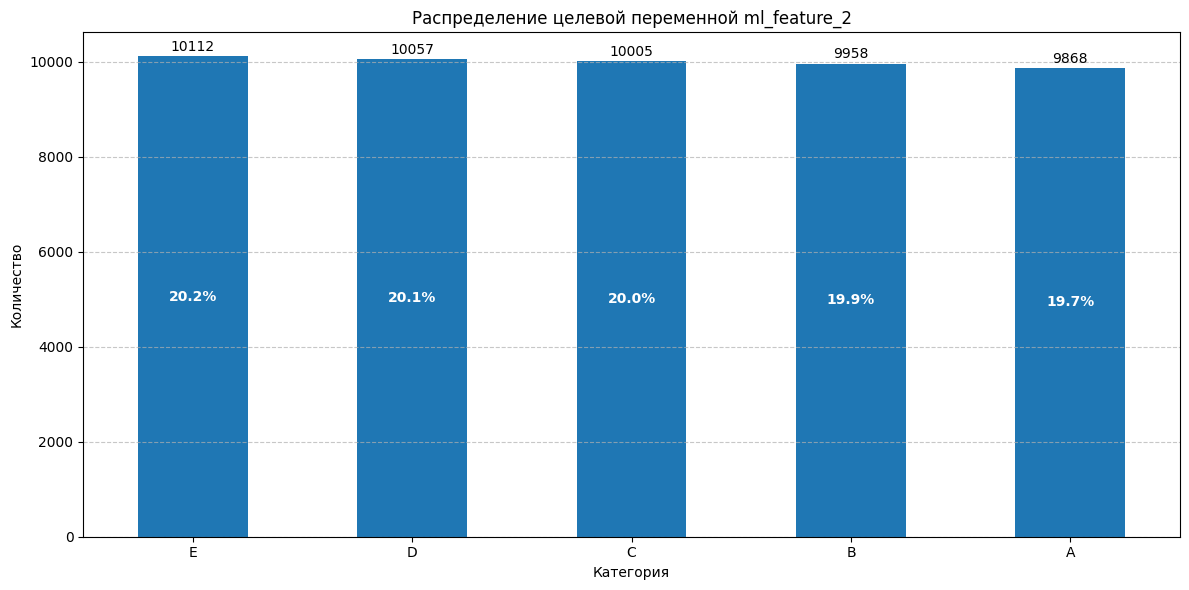

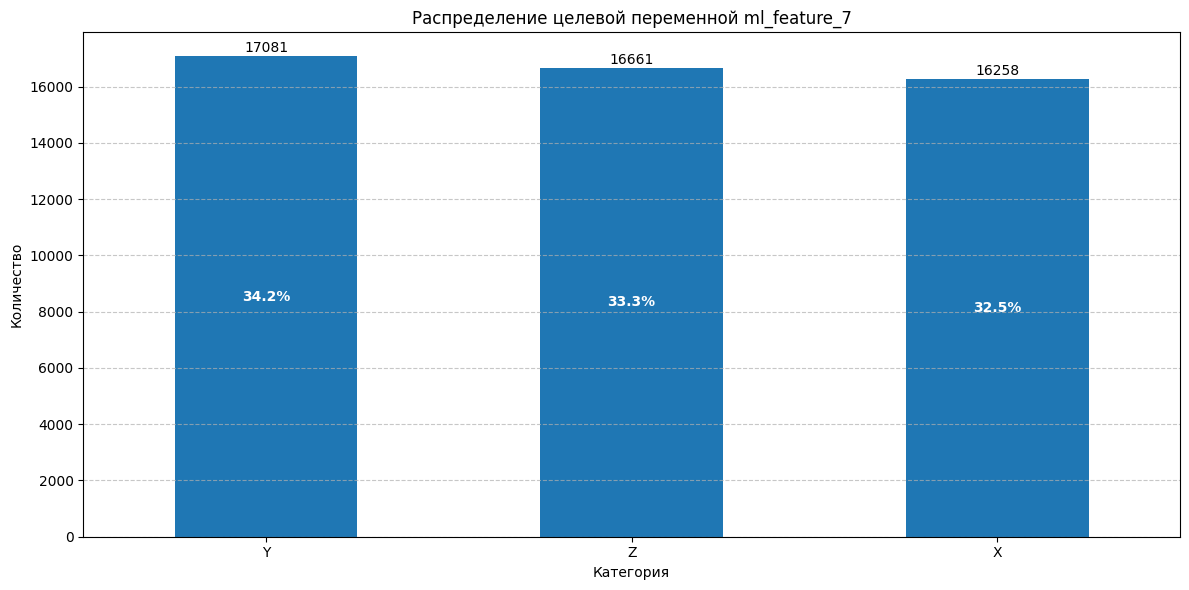

In [29]:
for feature in cat_features:
    if feature == 'hour':
        top_n = 24
        fs = (24, 6)
    else:
        top_n = 10
        fs = (12, 6)
    plot_bar_chart(data=df_work[feature], figsize=fs, title=f'Распределение целевой переменной {feature}', top_n=top_n)

In [30]:
df_work[cat_features].astype('str').describe()

,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,7,7,1497,8,9,387,4,64,59,2,24,149,1160,1013,18,976,67,22,5,3
top,1005,0,4687,320,50,1722,0,35,23,0,13,-1,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,E,Y
freq,45835,35883,1200,46787,47287,5637,21074,14964,10919,25098,3013,23443,18011,18645,20457,31989,33763,32388,10112,17081


In [31]:
# Разделяем категориальные признаки по выбору метода заполнения пропусков 
cat_features_fillna_mode = ['C1', 'C15', 'C16', 'C17', 'C19', 'C21', 'C20', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'banner_pos', 'hour']
cat_features_fillna_unknown = ['ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'C14', 'C18']

len(cat_features_fillna_mode + cat_features_fillna_unknown) - len(cat_features)

0

In [32]:
# Разделяем категориальные признаки по выбору метода кодирования
cat_features_ohe = ['ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'C1', 'C15', 'C16', 'C18', 'banner_pos']
cat_features_loo = ['C14', 'C17', 'C19', 'C20', 'C21', 'site_id', 'site_domain', 'app_id', 'app_domain', 'hour', 'app_category', 'site_category']

len(cat_features_ohe + cat_features_loo) - len(cat_features)

0

#### Анализ категориальных признаков

**1. Признаки, подходящие для One-Hot Encoding**

- `ml_feature_2` (5);
- `ml_feature_4` (2);
- `ml_feature_7` (3);
- `C1` (7);
- `C15` (8);
- `C16` (9);
- `C18` (4);
- `banner_pos` (4).

**2. Признаки с высокой кардинальностью (требуют специальных методов)**

- `C14` (1497);
- `C17` (387);
- `C19` (64);
- `C20` (149);
- `C21` (59);
- `site_id` (1160);
- `site_domain` (1013);
- `app_id` (976);
- `app_domain` (67);
- `hour` (24);
- `app_category` (22);
- `site_category` (18).

**3. Замена пропущенных значений в SimpleImputer**
Учитывая распределение значений в вкатегориальных переменных метод замены пропусков на моду будет использован в тех переменных, где есть явный дисбаланс в распределении (`C1`, `C15`, `C16`, `C17`, `C19`, `C21`, `C20`, `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `banner_pos`).
Признаки `ml_feature_2`, `ml_feature_7`, `C14`, `C18`, `ml_feature_4` имеют сбалансирвоанное распределение и замена пропусков будет осуществляться на заглушку 'unknown'.
Исключение составляет `hour`, где также наблюдается баланс распределения значений. Но здесь будет логично заполнить именно самым часто встречающимся значением 13. Вместе с ближайшим к нему значением **12** они в сумме собирают почти 12% показов баннеров. 

**Рекомендуемые методы обработки:**
- **Target Encoder**: замена категории на среднее значение целевой переменной (`click`) для этой категории.
- **LeaveOneOutEncoder**: замена категории на среднее значение целевой переменной с защитой от утечки данных.



#### Краткий итог

- **One-Hot Encoding:** `ml_feature_2`, `ml_feature_4`, `ml_feature_7`, `C1`, `C15`, `C16`, `C18`, `banner_pos`.
- **Target Encoder / LeaveOneOutEncoder:** `C14`, `C17`, `C19`, `C20`, `C21`, `site_id`, `site_domain`, `app_id`, `app_domain`, `hour`, `app_category`, `site_category`.
- **Замена пропусков (стратегия заполнения в SimpleImputer):**
  - **На моду (самое частое значение):** применяется к переменным с явным дисбалансом в распределении — `C1`, `C15`, `C16`, `C17`, `C19`, `C21`, `C20`, `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `banner_pos`.
  - **На заглушку `'unknown'`:** используется для сбалансированных признаков — `ml_feature_2`, `ml_feature_4`, `ml_feature_7`, `C14`, `C18`.
  - **Исключение (специальная логика для `hour`):** заполняется самым часто встречающимся значением **13**, так как вместе с ближайшим значением **12** они охватывают почти 12% показов баннеров.

___

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

In [33]:
df_work[num_features].describe()

,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


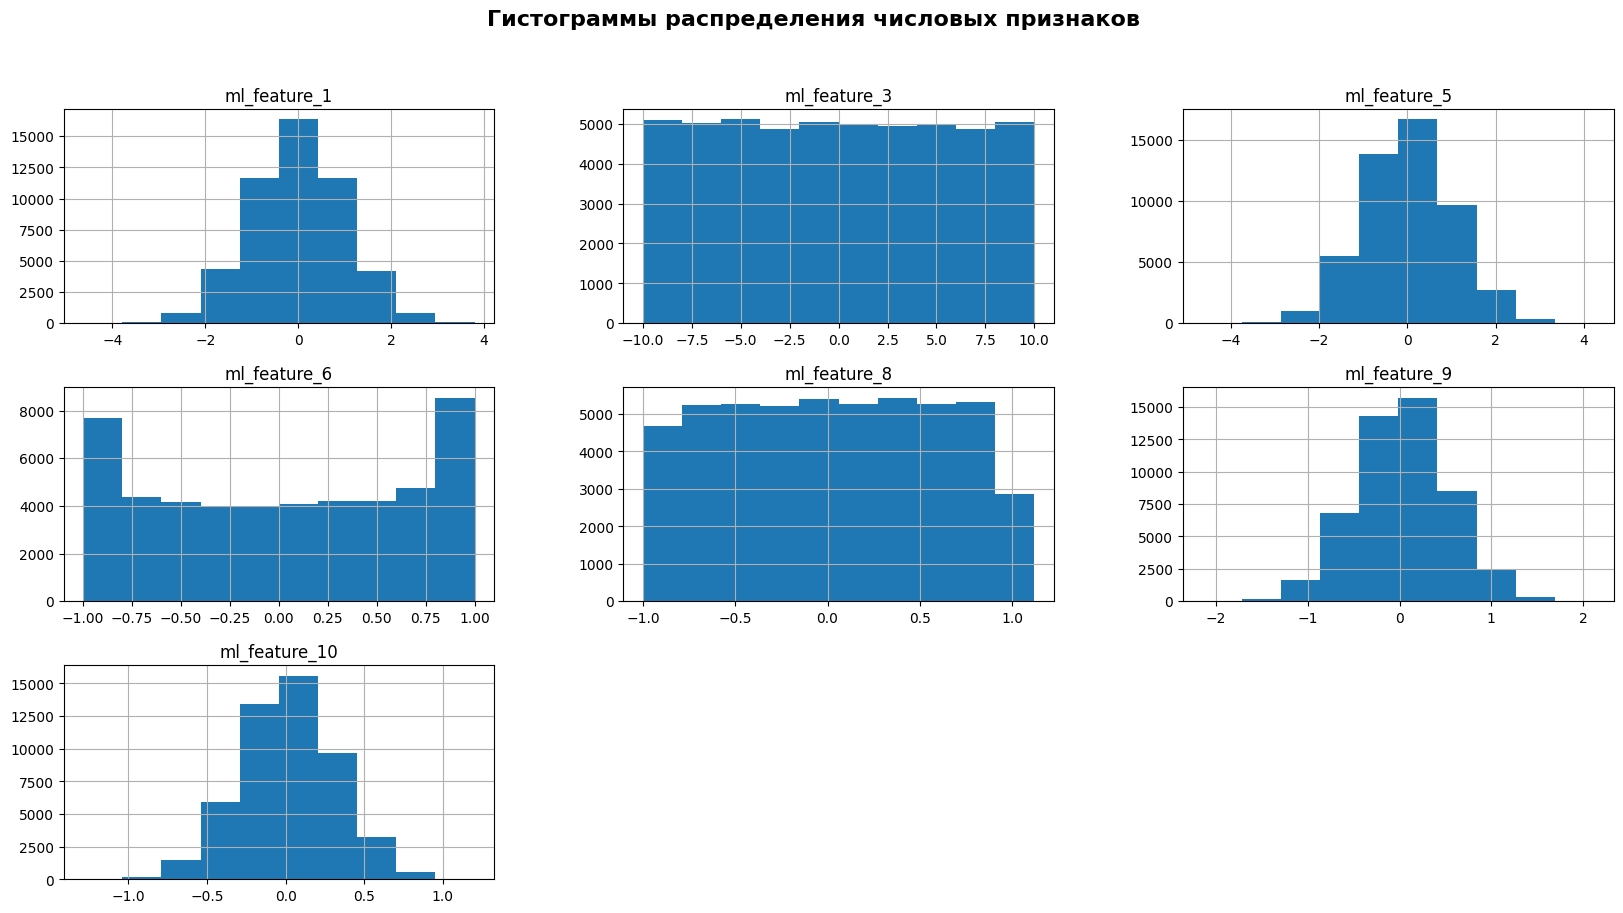

In [34]:
df_work[num_features].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, fontweight='bold')
plt.show()

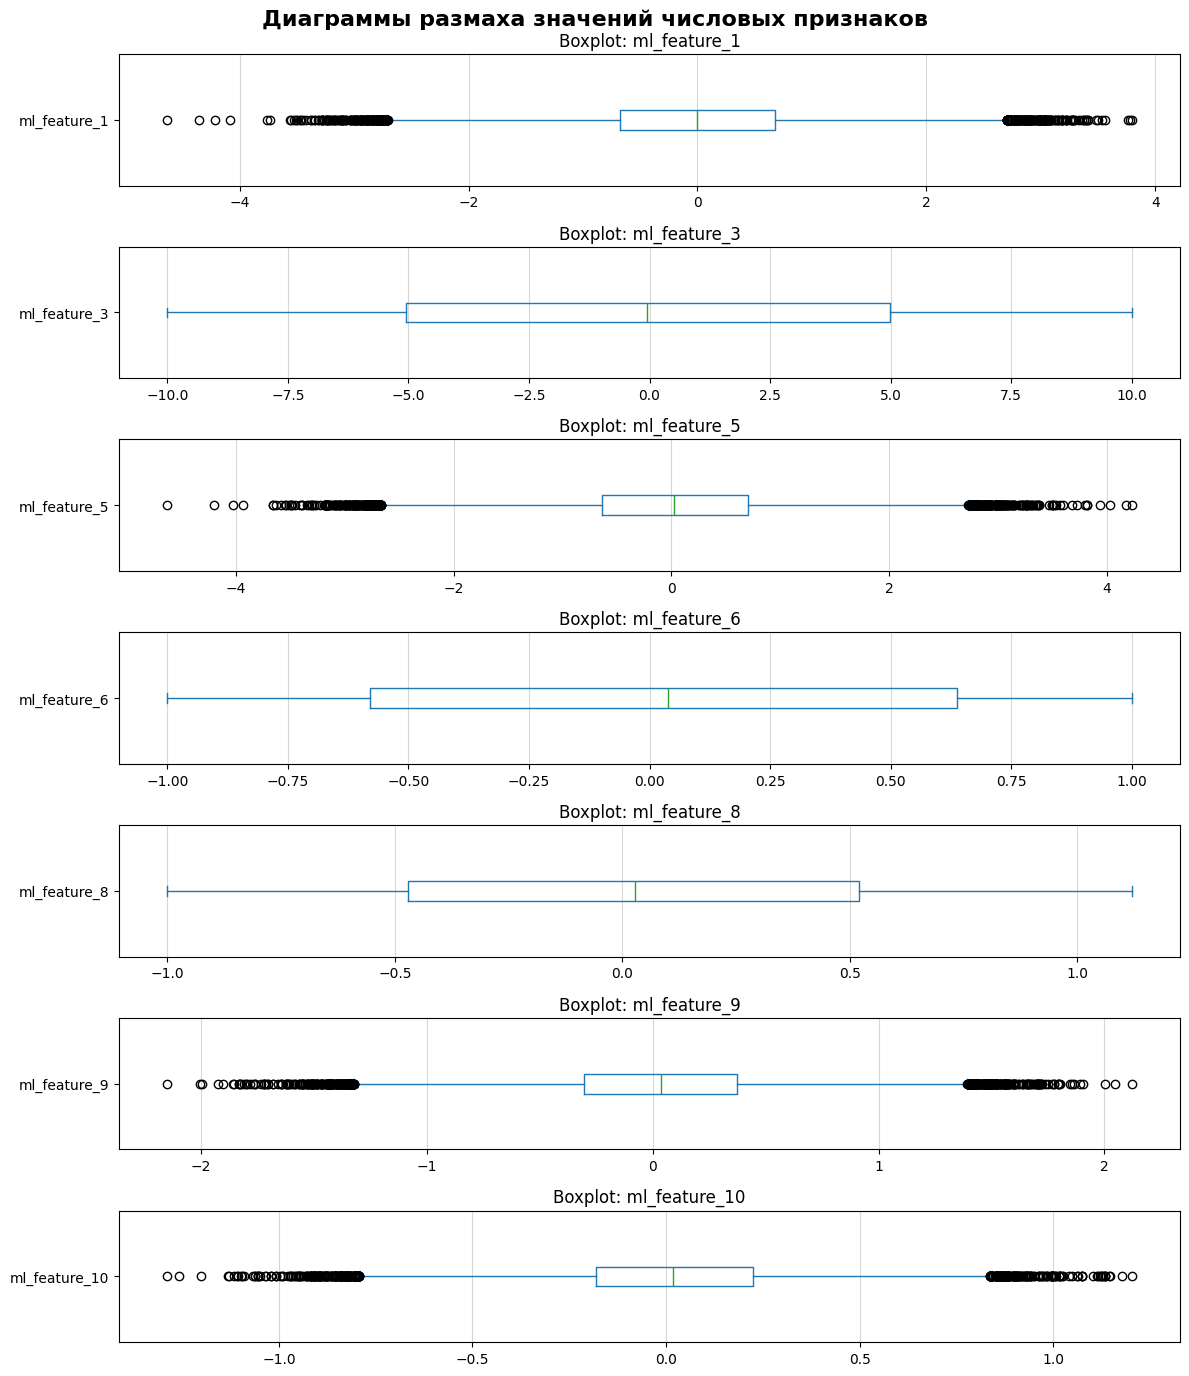

In [35]:
fig, axes = plt.subplots(nrows=len(num_features), ncols=1, figsize=(12, 2 * len(num_features)))

for i, feature in enumerate(num_features):
    df_work[feature].plot.box(ax=axes[i], vert=False)
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].grid(axis='x', alpha=0.5) 

plt.suptitle('Диаграммы размаха значений числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Комментарий по итогам анализа выбросов и распределения числовых признаков

Числовые признаки `ml_feature_1`, `ml_feature_5`, `ml_feature_9`, ml_feature_10 имеют распределение похожее на нормальное. Существуют значения за пределами нижних и верхних границ усов диаграммы размаха, которые можно трактовать как выбросы. И распределение симметрично. Выбросы также расположены симметрично не выглядят критично, чтобы требовать дополнительной обработки в виде замены на другие значения, логарифимирования (распределение симметрично), или извлечения квадратного корня. Выбросы принимаются как есть.

Признаки `ml_feature_3`(диапазон от -10 до 10) , `ml_feature_8` (от -1 до 1) имеют равномерное распределение с минимальными и максимальными значениями, определяющими границы диапазона значений без выбросов.

Признак `ml_feature_6` также расположен в граница заданного диапазона (-1, 1), но имеет ярко выраженные вершины по краям распределения. Выбросов нет.
___

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

In [36]:
df_work[target + num_features].corr(method='pearson').style.background_gradient(cmap='coolwarm')

,click,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
click,1.000000,0.002054,0.002935,0.062550,0.071566,0.080062,0.145883,0.130906
ml_feature_1,0.002054,1.000000,-0.001889,0.003125,0.003031,-0.000313,0.001853,0.004985
ml_feature_3,0.002935,-0.001889,1.000000,0.000332,-0.003392,-0.006767,0.001556,-0.004643
ml_feature_5,0.062550,0.003125,0.000332,1.000000,0.005570,0.008728,0.008086,0.007601
ml_feature_6,0.071566,0.003031,-0.003392,0.005570,1.000000,0.001491,0.011399,0.013620
ml_feature_8,0.080062,-0.000313,-0.006767,0.008728,0.001491,1.000000,0.012113,0.010767
ml_feature_9,0.145883,0.001853,0.001556,0.008086,0.011399,0.012113,1.000000,0.015627
ml_feature_10,0.130906,0.004985,-0.004643,0.007601,0.013620,0.010767,0.015627,1.000000


In [37]:
int_cols = [item for item in df_work.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns.tolist() + ['hour', 'C20'] if item not in target] # Обновим состав целочисленных категориальных признаков 

In [38]:
df_work[target + int_cols].corr(method='spearman').style.background_gradient(cmap='coolwarm')

,click,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20
click,1.000000,-0.048757,0.023058,-0.072136,-0.112777,0.130813,-0.064827,0.008595,-0.012409,-0.084017,-0.003141,-0.002909,-0.064544
C1,-0.048757,1.000000,0.251812,0.003544,0.082963,0.064259,0.004026,-0.039208,-0.035104,0.061205,-0.001006,0.012216,-0.004728
banner_pos,0.023058,0.251812,1.000000,-0.042373,0.090953,-0.119291,-0.064119,0.087049,0.175451,-0.164140,-0.009214,-0.000657,0.001450
C14,-0.072136,0.003544,-0.042373,1.000000,0.013371,-0.031778,0.976718,-0.150489,-0.023040,0.384854,0.012454,-0.052993,0.093935
C15,-0.112777,0.082963,0.090953,0.013371,1.000000,-0.550589,0.003161,-0.045027,0.082878,0.107070,-0.004170,-0.005442,0.054073
C16,0.130813,0.064259,-0.119291,-0.031778,-0.550589,1.000000,-0.018098,0.076502,-0.045092,-0.133977,0.001312,0.006883,-0.041623
C17,-0.064827,0.004026,-0.064119,0.976718,0.003161,-0.018098,1.000000,-0.162074,-0.038317,0.392314,0.013082,-0.053105,0.089011
C18,0.008595,-0.039208,0.087049,-0.150489,-0.045027,0.076502,-0.162074,1.000000,0.290856,-0.633207,-0.002855,0.020541,0.057252
C19,-0.012409,-0.035104,0.175451,-0.023040,0.082878,-0.045092,-0.038317,0.290856,1.000000,-0.254405,-0.006201,0.021365,0.197094
C21,-0.084017,0.061205,-0.164140,0.384854,0.107070,-0.133977,0.392314,-0.633207,-0.254405,1.000000,0.005849,-0.065215,0.007872


In [39]:
df_work[target + int_cols].corr(method='kendall').style.background_gradient(cmap='coolwarm')

,click,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20
click,1.000000,-0.048286,0.023036,-0.059100,-0.112328,0.130178,-0.053521,0.008027,-0.010787,-0.071543,-0.003141,-0.002428,-0.057014
C1,-0.048286,1.000000,0.249294,0.002708,0.081882,0.063336,0.003105,-0.036463,-0.030316,0.051464,-0.000996,0.010115,-0.003867
banner_pos,0.023036,0.249294,1.000000,-0.034733,0.090511,-0.118751,-0.052937,0.081240,0.152494,-0.139540,-0.009205,-0.000547,0.001238
C14,-0.059100,0.002708,-0.034733,1.000000,0.010365,-0.025305,0.938689,-0.119653,-0.012515,0.294172,0.010203,-0.035514,0.067133
C15,-0.112328,0.081882,0.090511,0.010365,1.000000,-0.549747,0.001967,-0.041818,0.071739,0.090778,-0.004153,-0.004523,0.047594
C16,0.130178,0.063336,-0.118751,-0.025305,-0.549747,1.000000,-0.014197,0.071033,-0.039009,-0.113453,0.001306,0.005712,-0.036615
C17,-0.053521,0.003105,-0.052937,0.938689,0.001967,-0.014197,1.000000,-0.130801,-0.023533,0.305918,0.010800,-0.035890,0.062134
C18,0.008027,-0.036463,0.081240,-0.119653,-0.041818,0.071033,-0.130801,1.000000,0.233773,-0.533650,-0.002666,0.017418,0.047188
C19,-0.010787,-0.030316,0.152494,-0.012515,0.071739,-0.039009,-0.023533,0.233773,1.000000,-0.184567,-0.005390,0.015026,0.149386
C21,-0.071543,0.051464,-0.139540,0.294172,0.090778,-0.113453,0.305918,-0.533650,-0.184567,1.000000,0.004980,-0.046920,0.008407


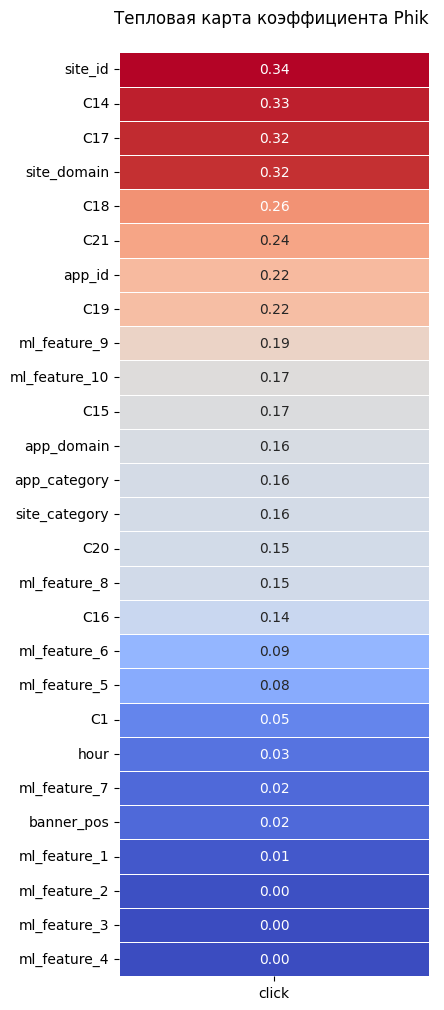

In [40]:
phik_coolwarm_matrix(df=df_work, target_var='click', interval_cols=num_features, matrix_view=False, figsize=(4, 12))

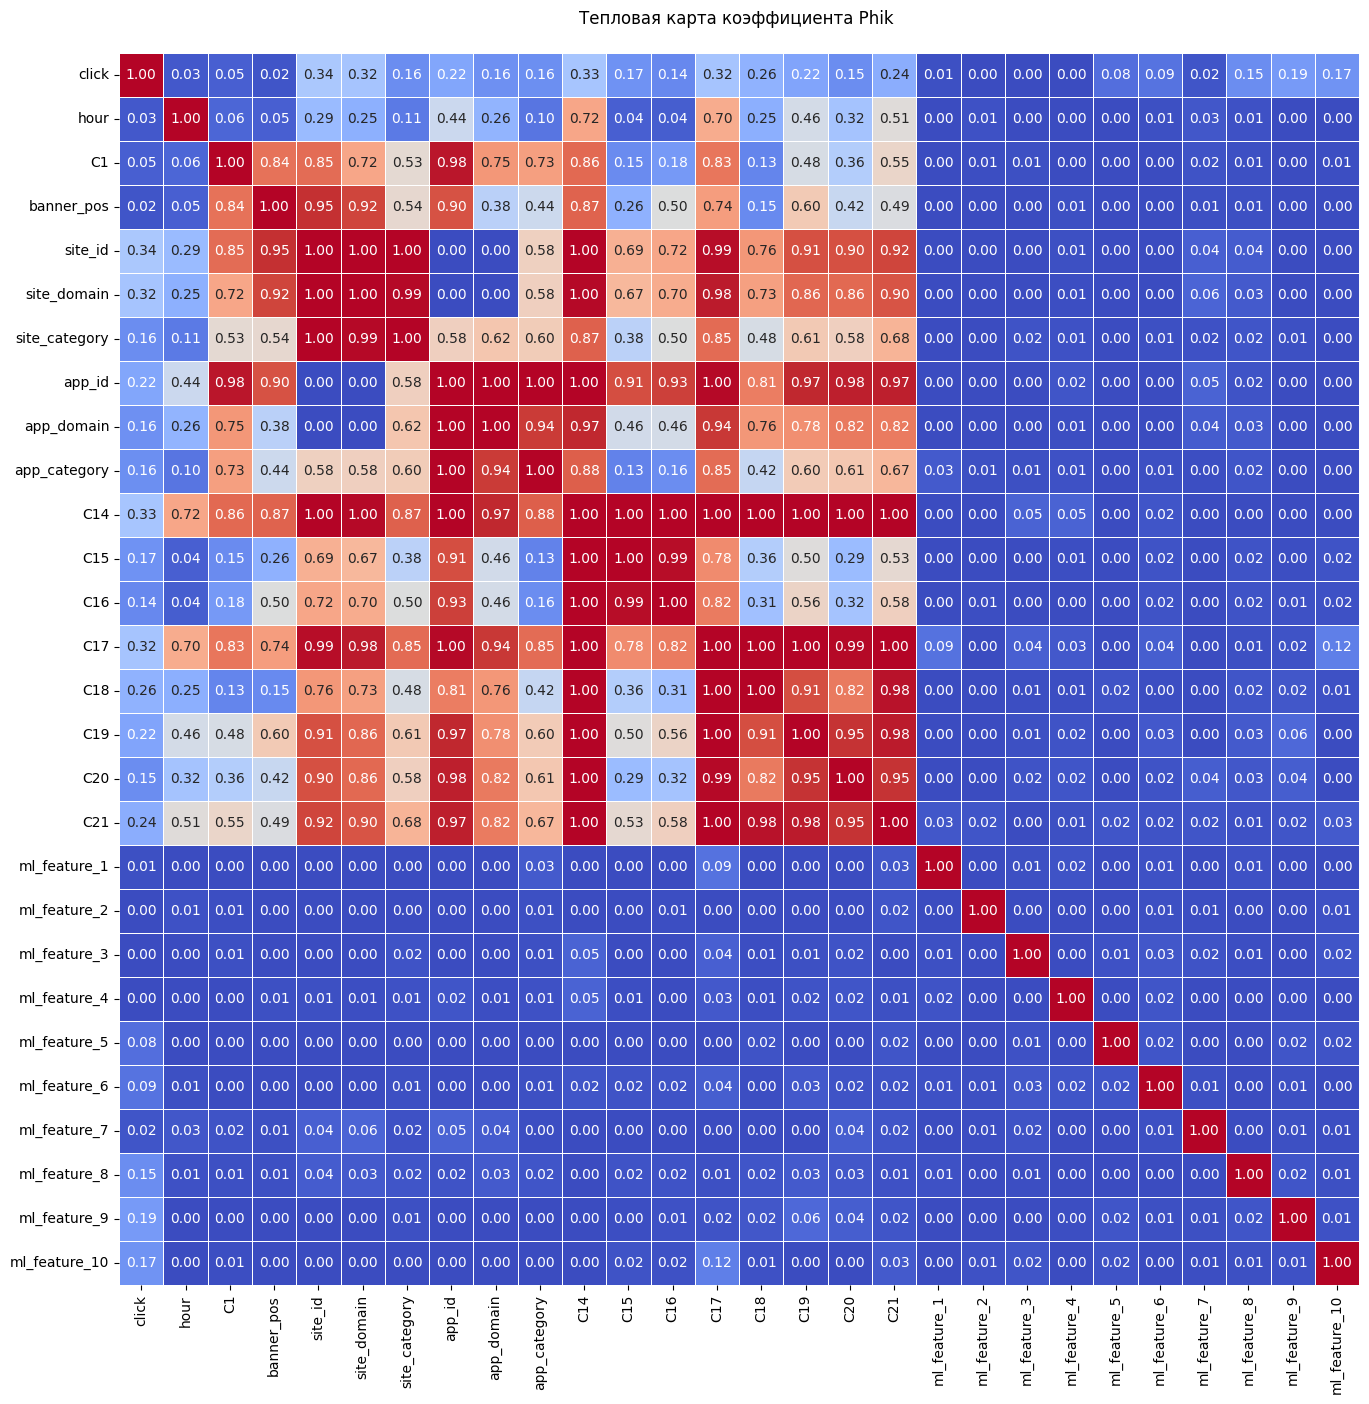

In [41]:
phik_coolwarm_matrix(df=df_work, target_var='click', interval_cols=num_features, figsize=(16, 16))

In [42]:
df_work[cat_features].astype('str').describe()

,C1,banner_pos,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,7,7,1497,8,9,387,4,64,59,2,24,149,1160,1013,18,976,67,22,5,3
top,1005,0,4687,320,50,1722,0,35,23,0,13,-1,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,E,Y
freq,45835,35883,1200,46787,47287,5637,21074,14964,10919,25098,3013,23443,18011,18645,20457,31989,33763,32388,10112,17081


In [46]:
# Признаки рекомендованные к удалению на основе анализа матриц корреляций
# columns_to_drop_2 = ['C1', 'app_id', 'app_category', 'C14', 'C17', 'C19', 'C20', 'C21', 'site_category', 'site_id', 'C16']
# columns_to_drop_2 = ['C1', 'app_category', 'app_domain', 'C15', 'C16', 'C17', 'C19', 'C20', 'site_category']
columns_to_drop_2 = ['C1', 'app_category', 'app_domain', 'C15', 'C16', 'C19', 'C20', 'site_category']

In [49]:
# Удалим ненужные колонки
df_work = optimize_dataframe(drop_unneccesary_columns(df_init, columns_to_drop + columns_to_drop_2))
# df_work = optimize_dataframe(drop_unneccesary_columns(df_work, columns_to_drop_2))
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   click          50000 non-null  int8   
 1   hour           50000 non-null  int32  
 2   banner_pos     50000 non-null  int8   
 3   site_id        50000 non-null  str    
 4   site_domain    50000 non-null  str    
 5   app_id         50000 non-null  str    
 6   C14            50000 non-null  int16  
 7   C17            50000 non-null  int16  
 8   C18            50000 non-null  int8   
 9   C21            50000 non-null  int16  
 10  ml_feature_1   50000 non-null  float32
 11  ml_feature_2   50000 non-null  str    
 12  ml_feature_3   50000 non-null  float32
 13  ml_feature_4   50000 non-null  int8   
 14  ml_feature_5   50000 non-null  float32
 15  ml_feature_6   50000 non-null  float32
 16  ml_feature_7   50000 non-null  str    
 17  ml_feature_8   50000 non-null  float32
 18  ml_feature_9   50

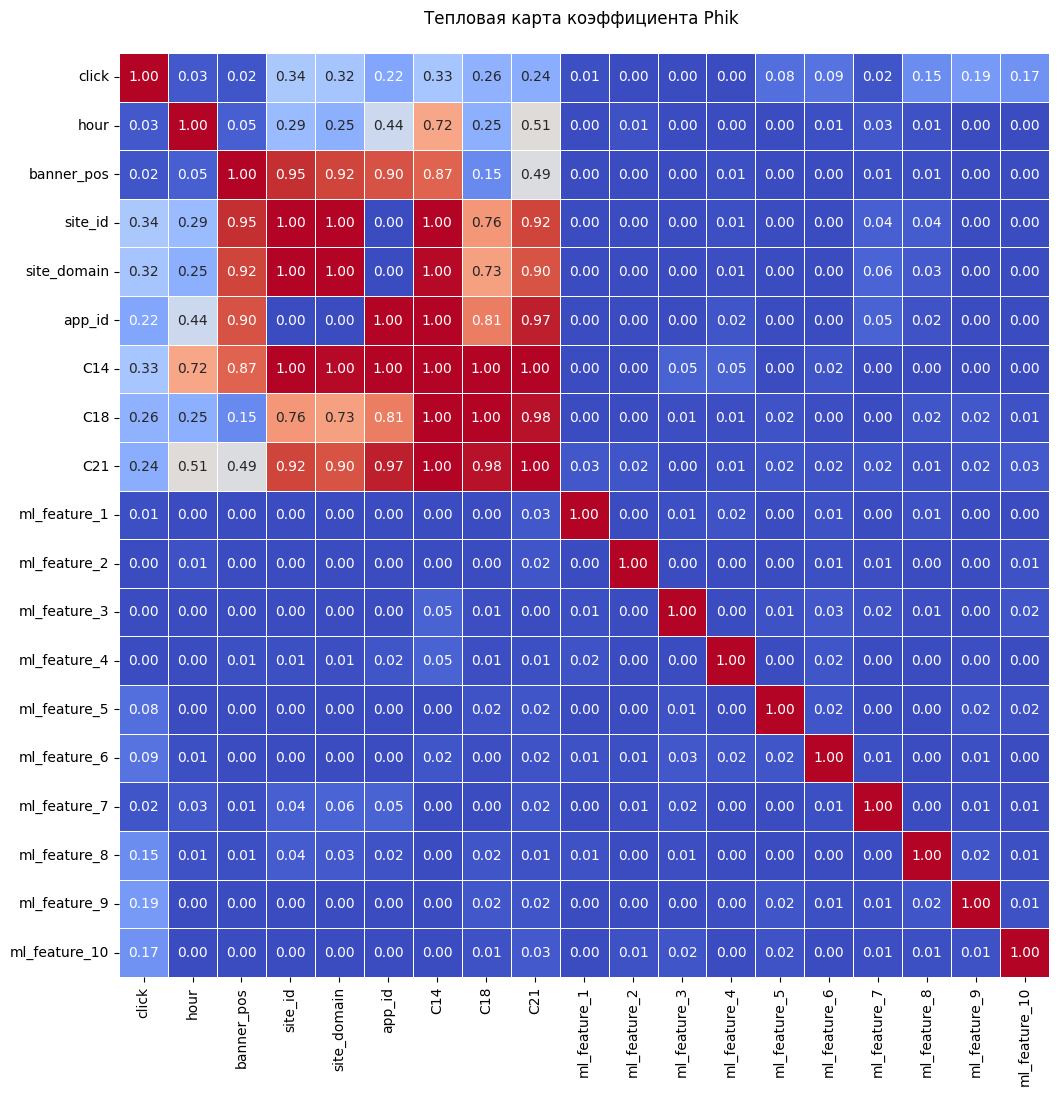

In [47]:
phik_coolwarm_matrix(df=df_work, target_var='click', interval_cols=num_features, figsize=(12, 12))

#### Комментарий по итогам анализа корреляций признаков с целевой переменной и между собой

Целевая переменная click не имеет сильной корреляции с числовыми признаками, согласно коэффициента корреляции Пирсона. Аналогично не обнаружено какой либо значимой корреляции с целочисленными категориальными признаками по коэффициентам Спирмана и Кендалла.

Согласно коэффициента Phik умеренная корреляция **0.32 - 0.34** наблюдается с признаками `site_domain`, `C17`, `C14`, `site_id`. Слабая корреляция 0.22 - 0.26 с признаками `C19`, `app_id`, `C21` и `C18`.

Остальные признаки не показывают значимой связи с целевой переменной.

Крайне высокая корреляция (0.90 - 1.00) наблюдается между признаком `app_id` и `C1` (0.98), `banner_pos` (0.90), `app_domain` (1.00), `app_category` (1.00), `C14` (1.00), `C15` (0.91), `C16` (0.93), `C17` (1.00), `C19` (0.97), `C20` (0.98), `C21` (0.97).
Другая группа признаков с высокой корреляцией (0.99-1.00) это `site_id`, `site_domain`, `site_category`. Третья группа признаков: `C15` и `C16`.

Такая высокая корреляция говорит о том, что признаки дублируют друг друга и необходимо удалить часть признаков и сделать выбор в пользу тех, что будут иметь баланс между обобщением и возможностью выявлять детали. Также нам нужно учитывать влияние на целевую переменную. Руководствуясь этой логикой можно оставить `app_domain` (67 уникальных значений) из первой группы, `site_domain` (1013 уникальных значений) из второй и `C15` (8 уникальных значений) - из третьей.

Итого рекомендованы к удалению признаки с корреляцией Phik между собой более 0.97: `C1`, `app_id`, `app_category`, `C14`, `C17`, `C19`, `C20`, `C21`, `site_category`, `site_id`, `C16`.

Матрица корреляций Phik сокращенного датасета намного более сбалансирована. 

___

### Выводы по EDA

**1. Ключевые находки**


* **Объём данных:** датасет содержит 50 000 объектов и 34 признака, без пропусков и дубликатов.
* **Дисбаланс классов в целевой переменной:** класс «не клик» (`0`) составляет 82,8 % (41 397 записей), класс «клик» (`1`) — 17,2 % (8 603 записи), соотношение примерно 5 : 1. Это требует особого подхода к выбору метрик оценки модели.
* **Типы данных:** в датасете присутствуют числовые (float, int) и категориальные (str) признаки.
* **Удаление несущественных признаков:** исключены идентификаторы показа баннера и признаки, описывающие устройство пользователя (`id`, `device_id`, `device_ip`, `device_model`, `device_type`, `device_conn_type`), так как они не влияют на решение о клике.
* **Корреляции:**
    * умеренная корреляция ($0{,}32–0{,}34$) с признаками `site_domain`, `C17`, `C14`, `site_id`;
    * слабая корреляция ($0{,}22–0{,}26$) с признаками `C19`, `app_id`, `C21` и `C18`;
    * высокая корреляция (0,90–1,00) между рядом признаков (например, `app_id` с `C1`, `banner_pos`, `app_domain` и др.), что требует удаления дублирующих признаков.
* **Распределение числовых признаков:**
    * нормальное распределение у `ml_feature_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10` (с симметричными выбросами);
    * равномерное распределение у `ml_feature_3`, `ml_feature_8` (без выбросов);
    * распределение с двумя вершинами по краям у `ml_feature_6` (без выбросов).
* **Кардинальность категориальных признаков:** часть признаков подходит для One‑Hot Encoding, другие требуют специальных методов (Target Encoder, LeaveOneOutEncoder) из‑за высокой кардинальности.

**2. Перспективные признаки для модели и обоснование выбора**

* `app_domain` (67 уникальных значений) — из группы с высокой корреляцией, баланс между обобщением и детализацией;
* `site_domain` (1013 уникальных значений) — аналогично, сохраняет информацию о площадке показа;
* `C15` (8 уникальных значений) — из группы коррелирующих признаков, низкая кардинальность;
* признаки с **умеренной корреляцией** ($0{,}32–0{,}34$): `site_domain`, `C17`, `C14`, `site_id`;
* признаки со **слабой корреляцией** ($0{,}22–0{,}26$): `C19`, `app_id`, `C21`, `C18`;
* остальные **категориальные признаки с низкой кардинальностью**, подходящие для One‑Hot Encoding: `ml_feature_2`, `ml_feature_4`, `ml_feature_7`, `C1`, `C16`, `C18`, `banner_pos`;
* **числовые признаки** (`ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`) — сохраняют информацию о контексте показа, несмотря на отсутствие сильной корреляции с целевой переменной.

**Обоснование:**
* **Связь с целевой переменной:** признаки с умеренной и слабой корреляцией напрямую влияют на вероятность клика.
* **Отсутствие дублирования:** рекомендованы к удалению признаки с корреляцией 0,97 и выше.
* **Баланс кардинальности:** сочетание признаков с низкой и высокой кардинальностью позволяет использовать разные методы кодирования без потери информации.
* **Контекстная значимость:** признаки описывают площадку показа (`site_*`, `app_*`), позицию баннера (`banner_pos`), время (`hour`) и агрегированные метрики (`ml_feature_*`), что важно для прогнозирования кликов.


**3. Действия по предобработке данных**

1. **Кодирование категориальных признаков:**
   * **One‑Hot Encoding:** для признаков с низкой кардинальностью (`ml_feature_2`, `ml_feature_4`, `ml_feature_7`, `C1`, `C15`, `C16`, `C18`, `banner_pos`).
   * **Target Encoder / LeaveOneOutEncoder:** для признаков с высокой кардинальностью (`C14`, `C17`, `C19`, `C20`, `C21`, `site_id`, `site_domain`, `app_id`, `app_domain`, `hour`, `app_category`, `site_category`).

2. **Заполнение пропусков (SimpleImputer):**
   * **На моду (самое частое значение):** для признаков с дисбалансом в распределении (`C1`, `C15`, `C16`, `C17`, `C19`, `C21`, `C20`, `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `banner_pos`).
   * **На заглушку `'unknown'`:** для сбалансированных признаков (`ml_feature_2`, `ml_feature_4`, `ml_feature_7`, `C14`, `C18`).
   * **Специальное заполнение для `hour`:** самым частым значением 13 (вместе с 12 охватывает 12 % показов).

3. **Обработка выбросов в числовых признаках:**
   * Для признаков с нормальным распределением (`ml_feature_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10`) не требуют обработки выбросов.
   * Признаки с равномерным (`ml_feature_3`, `ml_feature_8`) и бимодальным (`ml_feature_6`) распределением не требуют обработки выбросов.

___



## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [50]:
# Обновим датафрейм, так как признаки пока еще не удаляются, анализ продолжается
df_work = optimize_dataframe(drop_unneccesary_columns(df_init, columns_to_drop))

In [51]:
# =======================================================
# 1. РАЗДЕЛЯЕМ ПРИЗНАКИ И ЦЕЛЕВУЮ ПЕРЕМЕННУЮ
# =======================================================

X = df_work.drop(columns=['click'])
y = df_work['click']

# =======================================================
# 2. НЕЗАВИСИМОЕ РАЗБИЕНИЕ (Train, Calib, Test)
# =======================================================

# --- ШАГ 1: Отделяем финальный Тестовый набор (20% от N_TOTAL) ---
X_non_test, X_test, y_non_test, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
) 

# --- ШАГ 2: Делим оставшиеся данные на Train и Calib ---
# Выделяем Calib как 20% от оставшегося набора (X_non_test) 
# Train получит 80% от X_non_test
X_train_val, X_calib, y_train_val, y_calib = train_test_split(
    X_non_test, y_non_test, test_size=0.2, random_state=RANDOM_SEED, stratify=y_non_test
) 


# =======================================================
# 3. ПРОВЕРКА РАЗМЕРОВ И ЦЕЛЕЙ
# =======================================================

print(f"Общее количество образцов: {X.shape[0]}")
print("-" * 60)
print(f'{'Набор данных':<21} {'| Размер':<8} {'| Цель':<8}')
print("-" * 60)
print(f"Тренировочный (Train) | {len(X_train_val)}  | Обучение модели и CV-Валидация")
print(f"Калибровочный (Calib) | {len(X_calib)}   | Обучение Калибратора")
print(f"Тестовый (Test)       | {len(X_test)}  | Финальная независимая оценка")
print("-" * 60)
print(f"Сумма: {len(X_train_val) + len(X_calib) + len(X_test)}")

Общее количество образцов: 50000
------------------------------------------------------------
Набор данных          | Размер | Цель  
------------------------------------------------------------
Тренировочный (Train) | 32000  | Обучение модели и CV-Валидация
Калибровочный (Calib) | 8000   | Обучение Калибратора
Тестовый (Test)       | 10000  | Финальная независимая оценка
------------------------------------------------------------
Сумма: 50000


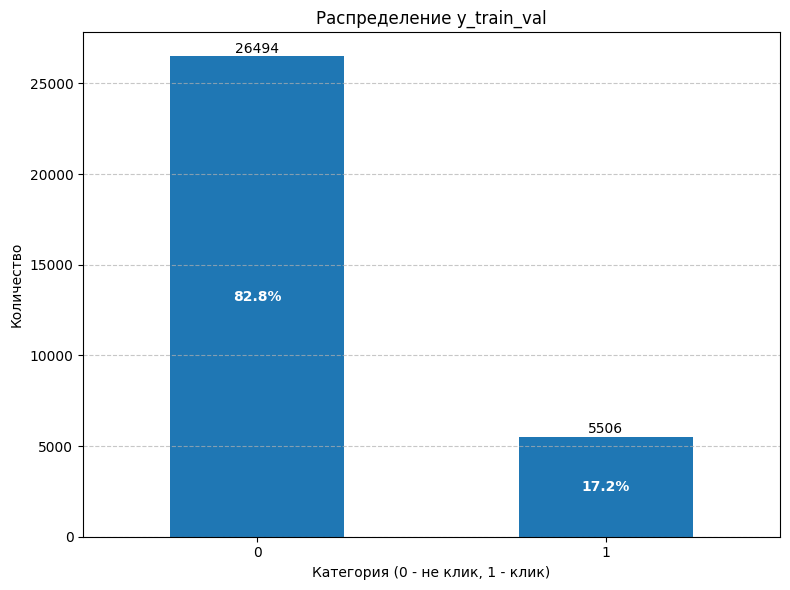

In [52]:
plot_bar_chart(data=y_train_val, figsize=(8, 6), xlabel='Категория (0 - не клик, 1 - клик)', ylabel='Количество', title='Распределение y_train_val')

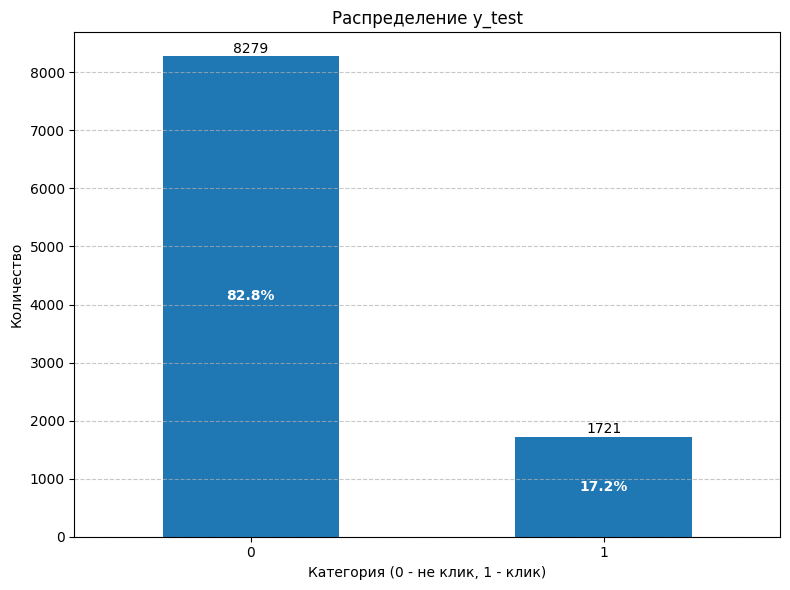

In [53]:
plot_bar_chart(data=y_test, figsize=(8, 6), xlabel='Категория (0 - не клик, 1 - клик)', ylabel='Количество', title='Распределение y_test')

### Комментарий

Выбока поделена на обучающую и тестовую в соотношении 80 к 20. Использовано стратифицированное раздение, баланс классов целевой переменной в обоих выборках сохранен.
___

## 4. Предобработка данных — построение пайплайнов

In [54]:
# Группы признаков для формирования пайплайнов
cat_features_mode_ohe = list(set(cat_features_fillna_mode) & set(cat_features_ohe))
cat_features_unknown_ohe = list(set(cat_features_fillna_unknown) & set(cat_features_ohe))
cat_features_mode_loo = list(set(cat_features_fillna_mode) & set(cat_features_loo))

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [55]:
# Доработаем кодировщик LeaveOneOutEncoder для получения корректных имен признаков
class NamedLeaveOneOutEncoder(LeaveOneOutEncoder):
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return input_features

In [56]:
# Пропуски в числовых признаках заполняются средним значением
num_imputer_mean = SimpleImputer(strategy='mean')

# Масштабирование при помощи StandardScaler
std_scaler = StandardScaler()

# Операторы заполнения пропусков категориальных признаков
cat_imputer_mode = SimpleImputer(strategy='most_frequent')
cat_imputer_unknown = SimpleImputer(strategy='constant', fill_value='unknown')

# Операторы кодирования категориальных переменных
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
loo_encoder = NamedLeaveOneOutEncoder()

# Создаем трансформеры
num_column_pipe = Pipeline(
    steps=[
        ('simple_imputer', num_imputer_mean),
        ('std_scaler', std_scaler)
    ]
)

cat_mode_ohe_pipe = Pipeline(
    steps=[
        ('imputer', cat_imputer_mode),
        ('ohe', one_hot_encoder)
    ]
)

cat_unknown_ohe_pipe = Pipeline(
    steps=[
        ('imputer', cat_imputer_unknown),
        ('ohe', one_hot_encoder)
    ]
)

cat_mode_loo_pipe = Pipeline(
    steps=[
        ('imputer', cat_imputer_mode),
        ('loo', loo_encoder)
    ]
)


# Строим общий трансформер

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_column_pipe, num_features),
        ('cmohe', cat_mode_ohe_pipe, cat_features_mode_ohe),
        ('cuohe', cat_unknown_ohe_pipe, cat_features_unknown_ohe),
        ('cmloo', cat_mode_loo_pipe, cat_features_mode_loo)
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cmohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [57]:
# Проверим работу preprocessor

X_transformed = preprocessor.fit_transform(X_train_val, y_train_val)

In [58]:
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

X_transformed_df.head()

,num__ml_feature_1,num__ml_feature_3,num__ml_feature_5,num__ml_feature_6,num__ml_feature_8,num__ml_feature_9,num__ml_feature_10,cmohe__C16_50,cmohe__C16_90,cmohe__C16_250,cmohe__C16_320,cmohe__C16_480,cmohe__C16_768,cmohe__C16_1024,cmohe__banner_pos_1,cmohe__banner_pos_2,cmohe__banner_pos_3,cmohe__banner_pos_4,cmohe__banner_pos_5,cmohe__banner_pos_7,cmohe__C1_1002,cmohe__C1_1005,cmohe__C1_1007,cmohe__C1_1008,cmohe__C1_1010,cmohe__C1_1012,cmohe__C15_300,cmohe__C15_320,cmohe__C15_480,cmohe__C15_728,cmohe__C15_768,cmohe__C15_1024,cuohe__ml_feature_2_B,cuohe__ml_feature_2_C,cuohe__ml_feature_2_D,cuohe__ml_feature_2_E,cuohe__ml_feature_7_Y,cuohe__ml_feature_7_Z,cuohe__C18_1,cuohe__C18_2,cuohe__C18_3,cuohe__ml_feature_4_1,cmloo__C17,cmloo__site_domain,cmloo__app_category,cmloo__site_id,cmloo__hour,cmloo__C20,cmloo__C19,cmloo__site_category,cmloo__app_id,cmloo__C21,cmloo__app_domain
0,-0.968258,-0.603119,-0.609690,-1.390403,0.064904,-0.287429,-0.254962,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.179601,0.214678,0.202623,0.214678,0.150609,0.191169,0.169284,0.214211,0.202226,0.179307,0.198317
1,0.418799,0.647150,1.423436,-1.539711,-0.170784,-0.550435,1.066980,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.103030,0.121925,0.105013,0.118357,0.158518,0.191235,0.169388,0.129266,0.203822,0.129959,0.203822
2,0.005458,1.082791,-0.581873,0.154184,-1.493845,-0.009906,1.618423,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.251316,0.121925,0.105013,0.118357,0.180023,0.239130,0.239088,0.129266,0.193662,0.238575,0.193662
3,1.157045,-0.682806,0.398739,0.682531,-0.507972,0.817280,-1.844909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.111111,0.121925,0.105013,0.118357,0.176727,0.213542,0.170424,0.129266,0.000000,0.208453,0.144359
4,0.326232,0.137621,0.636430,1.484685,-0.314779,0.558944,0.463185,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.242991,0.215859,0.202623,0.215859,0.158739,0.191169,0.238947,0.180704,0.202226,0.237903,0.198317


In [59]:
X_transformed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 53 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num__ml_feature_1      32000 non-null  float64
 1   num__ml_feature_3      32000 non-null  float64
 2   num__ml_feature_5      32000 non-null  float64
 3   num__ml_feature_6      32000 non-null  float64
 4   num__ml_feature_8      32000 non-null  float64
 5   num__ml_feature_9      32000 non-null  float64
 6   num__ml_feature_10     32000 non-null  float64
 7   cmohe__C16_50          32000 non-null  float64
 8   cmohe__C16_90          32000 non-null  float64
 9   cmohe__C16_250         32000 non-null  float64
 10  cmohe__C16_320         32000 non-null  float64
 11  cmohe__C16_480         32000 non-null  float64
 12  cmohe__C16_768         32000 non-null  float64
 13  cmohe__C16_1024        32000 non-null  float64
 14  cmohe__banner_pos_1    32000 non-null  float64
 15  cmohe__banner

In [60]:
print('Числовые признаки num_features: ', num_features)
print('Категориальные признаки с заполнением пропусков модой и OHE кодированием: ', cat_features_mode_ohe)
print('Категориальные признаки с заполнением пропусков константой "unknown" и OHE кодированием: ', cat_features_unknown_ohe)
print('Категориальные признаки с заполнением пропусков модой и LeaveOneOutEncoding: ', cat_features_mode_loo)

Числовые признаки num_features:  ['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
Категориальные признаки с заполнением пропусков модой и OHE кодированием:  ['C16', 'banner_pos', 'C1', 'C15']
Категориальные признаки с заполнением пропусков константой "unknown" и OHE кодированием:  ['ml_feature_2', 'ml_feature_7', 'C18', 'ml_feature_4']
Категориальные признаки с заполнением пропусков модой и LeaveOneOutEncoding:  ['C17', 'site_domain', 'app_category', 'site_id', 'hour', 'C20', 'C19', 'site_category', 'app_id', 'C21', 'app_domain']


### Комментарий по этапу предобработки данных и построения пайплайна

Создан пайплайн предобработки входящего датасета.

**Числовые признаки:** `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10` получают заполнение пропусков средним и проходят стандартизацию через StandardScaler.

**Категориальные признаки** делятся на 3 группы:
1. Признаки с заполнением пропусков модой и One Hot кодированием: `C1`, `banner_pos`, `C15`, `C16`.
2. Признаки с заполнением пропусков константой **'unknown'** и кодированием LeaveOneOutEncoder: `C18`, `ml_feature_2`, `ml_feature_4`, `ml_feature_7`.
3. Признаки с заполнением пропусков модой и One Hot кодированием: `C20`, `app_id`, `app_category`, `hour`, `C19`, `app_domain`, `site_domain`, `site_category`, `C21`, `site_id`, `C17`.

После применения **preprocessor** получен датасет с **53 признаками**.

___

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

In [61]:
# Числовые признаки с полностью 0 дисперсией отсутсвуют

vs_constant = VarianceThreshold(threshold=0.0) 
vs_constant.fit(df_work[num_features])

constant_num_columns = [col for col, keep in zip(num_features, vs_constant.get_support()) if not keep]

constant_num_columns

[]

In [62]:
# Есдинственный числовой признак с отсечкой по дисперсии 0.1
# Но все же это недостаточное основания для его удаления

vs_constant = VarianceThreshold(threshold=0.1) 
vs_constant.fit(df_work[num_features])

constant_num_columns = [col for col, keep in zip(num_features, vs_constant.get_support()) if not keep]

constant_num_columns

['ml_feature_10']

Взаимная информация признаков с click:
ml_feature_8     0.026410
ml_feature_9     0.011521
ml_feature_10    0.007686
ml_feature_6     0.006920
ml_feature_3     0.003248
ml_feature_5     0.002126
ml_feature_1     0.000000
dtype: float64


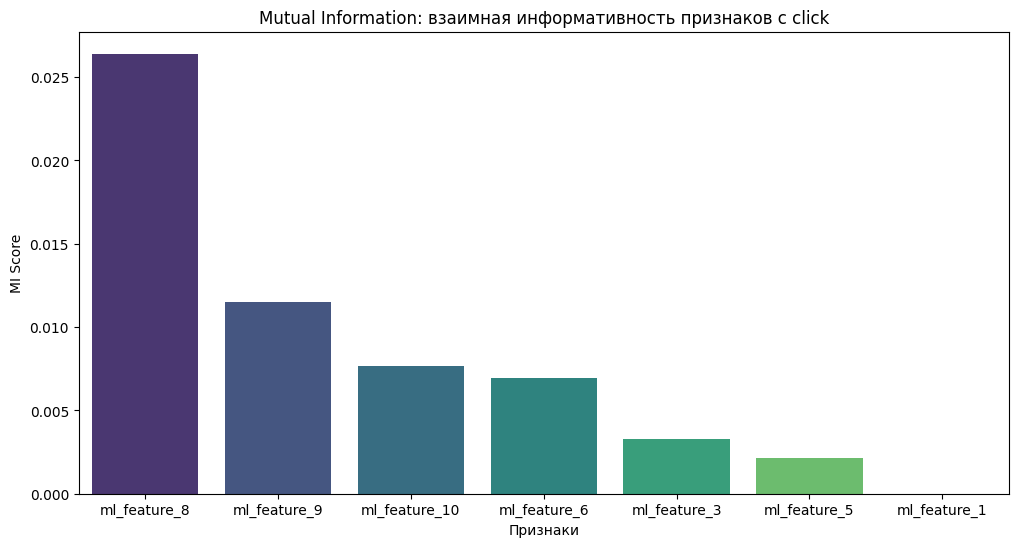

In [63]:
mi_scores = mutual_info_classif(X_train_val[num_features], y_train_val)
mi_scores = pd.Series(mi_scores, index=X_train_val[num_features].columns)
mi_scores = mi_scores.sort_values(ascending=False)

# Вывод результатов
print("Взаимная информация признаков с click:")
print(mi_scores)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")
plt.title("Mutual Information: взаимная информативность признаков с click")
plt.ylabel("MI Score")
plt.xlabel("Признаки")
plt.show()

In [64]:
cat_int_features = X_train_val.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns.tolist()
cat_int_features

['C1',
 'banner_pos',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C21',
 'ml_feature_4']

In [65]:
# Отбор категориальных признаков на основе Хи-квадрат
# Выбор топ-5 признаков

cat_int_features = X_train_val.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns.tolist()

select_k = 5
selection = SelectKBest(chi2, k=select_k).fit(X_train_val[cat_int_features].astype('str'), y_train_val)

# Вывод выбранных признаков
features = X_train_val[cat_int_features].astype('str').columns[selection.get_support()]
print("Выбранные признаки по критерию Хи-квадрат:", features.to_list())

Выбранные признаки по критерию Хи-квадрат: ['C14', 'C16', 'C17', 'C19', 'C21']


#### Комментарий по применению фильтрационных методов

Удаление признаков на основе баланса корреляции с целевой переменной и корреляции между признаами было проведено по итогам Исследовательского анализа данных в п. 2.7.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

In [66]:
# Разделим выборку X_transformed на тренировочную и валидационную
X_tr_train, X_tr_val, y_tr_train, y_tr_val = train_test_split(X_transformed_df, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_SEED)

In [69]:
model = LogisticRegression()
sfs_forward = SequentialFeatureSelector(
                                        model,
                                        n_features_to_select='auto',
                                        direction='forward',
                                        cv=3,
                                        scoring='f1',
                                        n_jobs=-1
                                    )

sfs_forward.fit(X_tr_train, y_tr_train)
# Получаем выбранные признаки
selected_ffs_features = X_tr_train.columns[sfs_forward.get_support()].tolist()
print(f'\nВыбранные признаки SFS (Forward):')
print(selected_ffs_features)

# Оцениваем модель с выбранными признаками
X_train_ffs_selected = sfs_forward.transform(X_tr_train)
X_val_ffs_selected = sfs_forward.transform(X_tr_val)

model.fit(X_train_ffs_selected, y_tr_train)
y_pred_ffs = model.predict(X_val_ffs_selected)

f1_ffs = f1_score(y_tr_val, y_pred_ffs)

print(f'F1 на валид. выборке с SFS (Forward): {f1_ffs:.4f}')

print("-" * 50)



Выбранные признаки SFS (Forward):
['cmohe__C16_90', 'cmohe__C16_320', 'cmohe__C16_480', 'cmohe__C16_768', 'cmohe__C16_1024', 'cmohe__banner_pos_2', 'cmohe__banner_pos_3', 'cmohe__banner_pos_5', 'cmohe__banner_pos_7', 'cmohe__C1_1002', 'cmohe__C1_1008', 'cmohe__C1_1012', 'cmohe__C15_480', 'cmohe__C15_728', 'cmohe__C15_768', 'cmohe__C15_1024', 'cuohe__ml_feature_2_D', 'cuohe__C18_3', 'cmloo__C17', 'cmloo__site_domain', 'cmloo__app_category', 'cmloo__site_id', 'cmloo__hour', 'cmloo__site_category', 'cmloo__app_id', 'cmloo__C21']
F1 на валид. выборке с SFS (Forward): 0.1872
--------------------------------------------------


In [70]:
len(selected_ffs_features)

26

In [78]:
estimator = LogisticRegression(solver='liblinear')
print("Запуск Recursive Feature Elimination (RFE) из sklearn...")

# Определим, сколько признаков хотим оставить
num_features_to_select = 39

rfe_selector = RFE(estimator=estimator,
                   n_features_to_select=num_features_to_select,
                   step=1,          # Количество признаков для удаления на каждой итерации (по умолчанию 1)
                   verbose=0)       # Уровень детализации вывода

# Обучаем RFE на обучающих данных
rfe_selector.fit(X_tr_train, y_tr_train)

# Получаем информацию о выбранных признаках
selected_rfe_features = X_tr_train.columns[rfe_selector.support_].tolist()
print(f'\nВыбранные признаки RFE ({num_features_to_select}): {selected_rfe_features}')

# rfe_selector.ranking_ - массив, показывающий ранг признаков (1 - наиболее важные, удалённые - больше 1)
print(f'Ранжирование признаков RFE: {rfe_selector.ranking_}')
# Чтобы сопоставить ранг с названием признака:
for feature, rank in zip(X_tr_train.columns, rfe_selector.ranking_):
    print(f'Признак: {feature}, Ранг: {rank}')


# Оцениваем модель с выбранными признаками на валидационной выборке
# Трансформируем данные, оставляя только выбранные признаки
X_train_rfe = rfe_selector.transform(X_tr_train)
X_val_rfe = rfe_selector.transform(X_tr_val)

# Обучаем финальную модель на сокращённом наборе признаков
estimator.fit(X_train_rfe, y_tr_train)
y_pred_rfe = estimator.predict(X_val_rfe)
f1_rfe = f1_score(y_tr_val, y_pred_rfe)
print(f'\nF1 на валид. выборке с RFE ({num_features_to_select} признаков): {f1_rfe:.4f}')

print("-" * 50)

Запуск Recursive Feature Elimination (RFE) из sklearn...

Выбранные признаки RFE (39): ['num__ml_feature_5', 'num__ml_feature_6', 'num__ml_feature_8', 'num__ml_feature_9', 'num__ml_feature_10', 'cmohe__C16_90', 'cmohe__C16_250', 'cmohe__C16_320', 'cmohe__C16_480', 'cmohe__C16_1024', 'cmohe__banner_pos_2', 'cmohe__banner_pos_3', 'cmohe__banner_pos_4', 'cmohe__banner_pos_5', 'cmohe__banner_pos_7', 'cmohe__C1_1002', 'cmohe__C1_1005', 'cmohe__C1_1007', 'cmohe__C1_1008', 'cmohe__C1_1010', 'cmohe__C1_1012', 'cmohe__C15_300', 'cmohe__C15_320', 'cmohe__C15_480', 'cmohe__C15_728', 'cmohe__C15_768', 'cuohe__ml_feature_7_Z', 'cuohe__C18_1', 'cmloo__C17', 'cmloo__site_domain', 'cmloo__app_category', 'cmloo__site_id', 'cmloo__hour', 'cmloo__C20', 'cmloo__C19', 'cmloo__site_category', 'cmloo__app_id', 'cmloo__C21', 'cmloo__app_domain']
Ранжирование признаков RFE: [13 15  1  1  1  1  1  3  1  1  1  1  8  1 11  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  7 14  6  5  4  2  1  1 12  9 10  1  1  1  

In [79]:
sorted(selected_rfe_features)

['cmloo__C17',
 'cmloo__C19',
 'cmloo__C20',
 'cmloo__C21',
 'cmloo__app_category',
 'cmloo__app_domain',
 'cmloo__app_id',
 'cmloo__hour',
 'cmloo__site_category',
 'cmloo__site_domain',
 'cmloo__site_id',
 'cmohe__C15_300',
 'cmohe__C15_320',
 'cmohe__C15_480',
 'cmohe__C15_728',
 'cmohe__C15_768',
 'cmohe__C16_1024',
 'cmohe__C16_250',
 'cmohe__C16_320',
 'cmohe__C16_480',
 'cmohe__C16_90',
 'cmohe__C1_1002',
 'cmohe__C1_1005',
 'cmohe__C1_1007',
 'cmohe__C1_1008',
 'cmohe__C1_1010',
 'cmohe__C1_1012',
 'cmohe__banner_pos_2',
 'cmohe__banner_pos_3',
 'cmohe__banner_pos_4',
 'cmohe__banner_pos_5',
 'cmohe__banner_pos_7',
 'cuohe__C18_1',
 'cuohe__ml_feature_7_Z',
 'num__ml_feature_10',
 'num__ml_feature_5',
 'num__ml_feature_6',
 'num__ml_feature_8',
 'num__ml_feature_9']


#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [80]:
# Признаки рекомендованные к удалению на основе анализа матриц корреляций на этапе исследовательского анализа данных, метода взаимной информации и оберточных методов
columns_to_drop_3 = ['app_domain', 'C14', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_6']

In [81]:
# Обновим датафрейм, так как признаки пока еще не удаляются, анализ продолжается
df_work = optimize_dataframe(drop_unneccesary_columns(df_init, columns_to_drop + columns_to_drop_3))

In [82]:
# Обновление групп признаков
cat_features = [item for item in cat_features if item not in columns_to_drop + columns_to_drop_3]
num_features = [item for item in num_features if item not in columns_to_drop + columns_to_drop_3]
cat_features_fillna_mode = [item for item in cat_features_fillna_mode if item not in columns_to_drop + columns_to_drop_3]
cat_features_fillna_unknown = [item for item in cat_features_fillna_unknown if item not in columns_to_drop + columns_to_drop_3]
cat_features_ohe = [item for item in cat_features_ohe if item not in columns_to_drop + columns_to_drop_3]
cat_features_loo = [item for item in cat_features_loo if item not in columns_to_drop + columns_to_drop_3]

# Группы признаков для формирования пайплайнов
cat_features_mode_ohe = list(set(cat_features_fillna_mode) & set(cat_features_ohe))
cat_features_unknown_ohe = list(set(cat_features_fillna_unknown) & set(cat_features_ohe))
cat_features_mode_loo = list(set(cat_features_fillna_mode) & set(cat_features_loo))

In [83]:
# Создаем класс для отбора признаков и последующей передачи в общий пайплайн
class RFEFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, estimator, n_features_to_select=25, step=1, verbose=0):
        self.estimator = estimator
        self.n_features_to_select = n_features_to_select
        self.step = step
        self.verbose = verbose
        self.rfe_selector = None
        self.selected_indices_ = None

    def fit(self, X, y=None):
        # Инициализируем RFE с тем же estimator
        self.rfe_selector = RFE(
            estimator=self.estimator,
            n_features_to_select=self.n_features_to_select,
            step=self.step,
            verbose=self.verbose
        )
        # Обучаем RFE на данных
        self.rfe_selector.fit(X, y)
        # Сохраняем индексы выбранных признаков
        self.selected_indices_ = self.rfe_selector.support_
        return self

    def transform(self, X):
        # Возвращаем только выбранные признаки
        if self.selected_indices_ is None:
            raise ValueError("Selector not fitted yet.")
        return X.iloc[:, self.selected_indices_] if hasattr(X, 'iloc') else X[:, self.selected_indices_]

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.input_features_
        return input_features[self.selected_indices_]


In [84]:

# Строим общий трансформер
# Создаём пайплайн с предобработкой и отбором признаков

preprocessor_selector = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', RFEFeatureSelector(
        estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_SEED),
        n_features_to_select=39
    ))
])

preprocessor_selector


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cmohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [85]:
preprocessor_selector.fit(X_train_val, y_train_val)
X_train_selected = preprocessor_selector.transform(X_train_val)

In [86]:
pd.DataFrame(X_train_selected, columns=preprocessor_selector.get_feature_names_out()).info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num__ml_feature_5      32000 non-null  float64
 1   num__ml_feature_6      32000 non-null  float64
 2   num__ml_feature_8      32000 non-null  float64
 3   num__ml_feature_9      32000 non-null  float64
 4   num__ml_feature_10     32000 non-null  float64
 5   cmohe__C16_90          32000 non-null  float64
 6   cmohe__C16_250         32000 non-null  float64
 7   cmohe__C16_320         32000 non-null  float64
 8   cmohe__C16_480         32000 non-null  float64
 9   cmohe__C16_768         32000 non-null  float64
 10  cmohe__C16_1024        32000 non-null  float64
 11  cmohe__banner_pos_2    32000 non-null  float64
 12  cmohe__banner_pos_3    32000 non-null  float64
 13  cmohe__banner_pos_4    32000 non-null  float64
 14  cmohe__banner_pos_5    32000 non-null  float64
 15  cmohe__banner

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

In [87]:
# Выбираем метрики модели Precision, Recall, F1, PR-AUC
scoring = ['average_precision', 'precision', 'recall', 'f1']

# Собираем кросс-валидацию
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [88]:
# Создание модели DummyClassifier

dummy_classifier = DummyClassifier(strategy='prior', random_state=RANDOM_SEED)

cv_dummy = cross_validate(
    estimator=dummy_classifier,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold
)

# Записываем результаты dummy модели
cv_dummy_means = {
    'pr_auc': cv_dummy['test_average_precision'].mean().round(3),
    'precision': cv_dummy['test_precision'].mean().round(3),
    'recall': cv_dummy['test_recall'].mean().round(3),
    'f1': cv_dummy['test_f1'].mean().round(3)
} 

cv_dummy_means

{'pr_auc': np.float64(0.172),
 'precision': np.float64(0.0),
 'recall': np.float64(0.0),
 'f1': np.float64(0.0)}

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.



In [89]:
# Выбираем метрики модели PR-AUC, Precision, Recall, F1 
scoring = ['average_precision', 'precision', 'recall', 'f1']

# Собираем кросс-валидацию
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [90]:
# Обновим пайплан обработки, добавив модель LogisticRegression

model_LR = LogisticRegression(random_state=RANDOM_SEED)

pipeline_LR = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', RFEFeatureSelector(
        estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_SEED),
        n_features_to_select=39)
    ),
    ('model_LR', model_LR)

])

pipeline_LR

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cmohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [ ]:
# Создаем объект кросс валидации

cv_LR_model = cross_validate(
    estimator=pipeline_LR,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    return_estimator=True
)
# Забираем полученные коэффициенты
all_coefficients = []
for i, estimator in enumerate(cv_LR_model['estimator']):
    logreg = estimator.named_steps['model_LR']
    coefs = logreg.coef_[0]
    all_coefficients.append(coefs)

coef_array = np.array(all_coefficients)
mean_coef = np.mean(coef_array, axis=0)

# Берём первый пайплайн из кросс‑валидации
fitted_pipeline = cv_LR_model['estimator'][0]

# Извлекаем имена после предобработки
preprocessed_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Получаем индексы отобранных признаков и применяем к именам
selected_indices = fitted_pipeline.named_steps['feature_selector'].selected_indices_
selected_features_flat = preprocessed_names[selected_indices]

# Собираем метрики
cv_lr_means = {
    'pr_auc': cv_LR_model['test_average_precision'].mean().round(3),
    'precision': cv_LR_model['test_precision'].mean().round(3),
    'recall': cv_LR_model['test_recall'].mean().round(3),
    'f1': cv_LR_model['test_f1'].mean().round(3)
} 

# Выводим признаки и полученные коэффициенты модели
pd.DataFrame([mean_coef.round(4)], columns=selected_features_flat).T.sort_values(by=0, ascending=False)

,0
cmloo__app_id,1.9132
cmloo__site_domain,1.8468
cmloo__C21,1.7200
cmloo__C17,1.2667
cmloo__site_id,0.9523
cmloo__C19,0.8970
cmloo__hour,0.6340
cmloo__C20,0.5247
num__ml_feature_9,0.4115
cmohe__C16_480,0.3397


In [92]:
fit_results(cv_LR_model)

Результаты модели на кросс-валидации (средние значения):
--------------------------------------------------
pr_auc: 0.417
precision:   0.626
recall: 0.133
f1:   0.219
Результаты модели на кросс-валидации (стандартные отклонения):
--------------------------------------------------
pr_auc: 0.020
precision:   0.038
recall: 0.009
f1:   0.014


In [93]:
compare_model_results(cv_dummy_means, cv_lr_means, model_est_name='LogisticRgression', model_base_name='Dummy')

Результаты модели LogisticRgression (средние значения):
--------------------------------------------------
PR-AUC: 0.417
precision:  0.626
recall:  0.133
F1:     0.219

Сравнение моделей:
--------------------------------------------------
Метрика      Dummy        LogisticRgression Изменение 
--------------------------------------------------
PR_AUC       0.172        0.417        +0.245    
F1           0.000        0.219        +0.219    
PRECISION    0.000        0.626        +0.626    
RECALL       0.000        0.133        +0.133    


### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

In [ ]:
model_SVM_L = SVC(
    kernel='linear', 
    random_state=RANDOM_SEED,
    probability=False
)

pipeline_SVM_L = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', RFEFeatureSelector(
        estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_SEED),
        n_features_to_select=30)
    ),
    ('model_SVM', model_SVM_L)

])

pipeline_SVM_L

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cmohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [95]:
cv_SVM_L_model = cross_validate(
    estimator=pipeline_SVM_L,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    return_estimator=True
)

# Забираем коэффициенты из всех фолдов
all_coefficients = []
for i, estimator in enumerate(cv_SVM_L_model['estimator']):
    svm = estimator.named_steps['model_SVM']
    coefs = svm.coef_[0]  # для бинарной классификации
    all_coefficients.append(coefs)

coef_array = np.array(all_coefficients)
mean_coef = np.mean(coef_array, axis=0)

# Берём первый пайплайн из кросс‑валидации
fitted_pipeline = cv_SVM_L_model['estimator'][0]

# Извлекаем имена после предобработки
preprocessed_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Получаем индексы отобранных признаков и применяем к именам
selected_indices = fitted_pipeline.named_steps['feature_selector'].selected_indices_
selected_features_flat = preprocessed_names[selected_indices]

# Собираем метрики
cv_svm_l_means = {
    'pr_auc': cv_SVM_L_model['test_average_precision'].mean().round(3),
    'precision': cv_SVM_L_model['test_precision'].mean().round(3),
    'recall': cv_SVM_L_model['test_recall'].mean().round(3),
    'f1': cv_SVM_L_model['test_f1'].mean().round(3)
} 

# Выводим признаки и коэффициенты модели
result_df = pd.DataFrame(
    [mean_coef.round(4)],
    columns=selected_features_flat
).T.sort_values(by=0, ascending=False)

result_df


,0
cmohe__banner_pos_2,0.1998
cmohe__C15_768,0.1998
cmloo__app_id,0.0006
cmloo__site_category,0.0005
cmloo__C17,0.0004
cuohe__C18_1,0.0003
cmloo__C20,0.0003
cmloo__site_id,0.0002
cmloo__C19,0.0002
cmohe__banner_pos_7,0.0002


In [96]:
fit_results(cv_SVM_L_model)

Результаты модели на кросс-валидации (средние значения):
--------------------------------------------------
pr_auc: 0.377
precision:   0.000
recall: 0.000
f1:   0.000
Результаты модели на кросс-валидации (стандартные отклонения):
--------------------------------------------------
pr_auc: 0.020
precision:   0.000
recall: 0.000
f1:   0.000



### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [97]:
compare_model_results(cv_dummy_means, cv_lr_means, 'LogReg', 'Dummy')

Результаты модели LogReg (средние значения):
--------------------------------------------------
PR-AUC: 0.417
precision:  0.626
recall:  0.133
F1:     0.219

Сравнение моделей:
--------------------------------------------------
Метрика      Dummy        LogReg       Изменение 
--------------------------------------------------
PR_AUC       0.172        0.417        +0.245    
F1           0.000        0.219        +0.219    
PRECISION    0.000        0.626        +0.626    
RECALL       0.000        0.133        +0.133    


In [98]:
compare_model_results(cv_lr_means, cv_svm_l_means, 'SVM Linear', 'LogReg')

Результаты модели SVM Linear (средние значения):
--------------------------------------------------
PR-AUC: 0.377
precision:  0.000
recall:  0.000
F1:     0.000

Сравнение моделей:
--------------------------------------------------
Метрика      LogReg       SVM Linear   Изменение 
--------------------------------------------------
PR_AUC       0.417        0.377        -0.040    
F1           0.219        0.000        -0.219    
PRECISION    0.626        0.000        -0.626    
RECALL       0.133        0.000        -0.133    


## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.



In [127]:
# Обновим модель опорных векторов SVM
model_SVM = SVC(
    random_state=RANDOM_SEED,
    probability=False
)

pipeline_SVM = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', RFEFeatureSelector(
        estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_SEED),
        n_features_to_select=30)
    ),
    ('model_SVM', model_SVM)

])

In [128]:
# Параметрическая сетка LogisticRegression
param_grid_lr = {
    'model_LR__C': [0.01, 0.1, 1, 10],
    'model_LR__solver': ['lbfgs', 'liblinear']
}

# Параметрическая сетка SVM 
param_grid_svm= {
    'model_SVM__C': [1, 10],
    'model_SVM__kernel': ['linear','rbf'],
}


#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

In [124]:
# Создайте объект GridSearchCV
grid_lr = GridSearchCV(
    estimator=pipeline_LR,              # объект с пайплайном
    param_grid=param_grid_lr,           # словарь с сеткой гиперпараметров
    cv=kfold,                           # 5-фолдовая стратифицированная кросс-валидация
    scoring=scoring,                    # словарь с названиями метрик для оценки моделей
    refit='average_precision',          # выбираем лучшую модель по PR AUC
    n_jobs=-1,                          # использовать все ядра процессора
    verbose=1                           # краткий вывод информации
)

# Запуск поиска
grid_lr.fit(X_train_val, y_train_val)

# Сохраняем лучшую комбинацию гиперпараметров в отдельную переменную
best_params_lr = grid_lr.best_params_

# Сохраняем лучшую модель в отдельную переменную
best_estimator_lr = grid_lr.best_estimator_

# Сохраняем лучший результат pr_auc в отдельную переменную, округлив результат до 3 знаков после запятой
best_score_lr = round(grid_lr.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_lr)
print("Лучшая модель:", best_estimator_lr)
print("Лучший средний результат PR-AUC на кросс-валидации:", best_score_lr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие гиперпараметры: {'model_LR__C': 1, 'model_LR__solver': 'lbfgs'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
                       

In [129]:
# Создайте объект GridSearchCV
grid_svm = GridSearchCV(
    estimator=pipeline_SVM,             # объект с пайплайном
    param_grid=param_grid_svm,          # словарь с сеткой гиперпараметров
    cv=kfold,                           # 5-фолдовая стратифицированная кросс-валидация
    scoring=scoring,                    # словарь с названиями метрик для оценки моделей
    refit='average_precision',          # выбираем лучшую модель по PR AUC
    n_jobs=-1,                          # использовать все ядра процессора
    verbose=1                           # краткий вывод информации
)

# Запуск поиска
grid_svm.fit(X_train_val, y_train_val)

# Сохраняем лучшую комбинацию гиперпараметров в отдельную переменную
best_params_svm = grid_svm.best_params_

# Сохраняем лучшую модель в отдельную переменную
best_estimator_svm = grid_svm.best_estimator_

# Сохраняем лучший результат pr_auc в отдельную переменную, округлив результат до 3 знаков после запятой
best_score_svm = round(grid_svm.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_svm)
print("Лучшая модель:", best_estimator_svm)
print("Лучший средний результат PR-AUC на кросс-валидации:", best_score_svm)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие гиперпараметры: {'model_SVM__C': 1, 'model_SVM__kernel': 'linear'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
                    

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [130]:
results_lr = pd.DataFrame(grid_lr.cv_results_)
results_lr = results_lr[['params', 'mean_test_average_precision', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].sort_values('mean_test_average_precision', ascending = False)
results_svm = pd.DataFrame(grid_svm.cv_results_)
results_svm = results_svm[['params', 'mean_test_average_precision', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']].sort_values('mean_test_average_precision', ascending = False)
pd.concat([results_lr, results_svm], ignore_index=True).sort_values('mean_test_average_precision', ascending = False).head(10)

,params,mean_test_average_precision,mean_test_precision,mean_test_recall,mean_test_f1
0,"{'model_LR__C': 1, 'model_LR__solver': 'lbfgs'}",0.416995,0.626170,0.132766,0.218943
1,"{'model_LR__C': 1, 'model_LR__solver': 'liblinear'}",0.416898,0.623724,0.131131,0.216551
2,"{'model_LR__C': 10, 'model_LR__solver': 'lbfgs'}",0.416533,0.621263,0.134037,0.220334
3,"{'model_LR__C': 10, 'model_LR__solver': 'liblinear'}",0.416218,0.618399,0.133856,0.219964
4,"{'model_LR__C': 0.1, 'model_LR__solver': 'lbfgs'}",0.414556,0.641383,0.117691,0.198708
5,"{'model_LR__C': 0.1, 'model_LR__solver': 'liblinear'}",0.414239,0.644644,0.116964,0.197766
6,"{'model_LR__C': 0.01, 'model_LR__solver': 'lbfgs'}",0.399992,0.681063,0.068290,0.124003
7,"{'model_LR__C': 0.01, 'model_LR__solver': 'liblinear'}",0.390039,0.670020,0.075376,0.135180
8,"{'model_SVM__C': 1, 'model_SVM__kernel': 'linear'}",0.376694,0.000000,0.000000,0.000000
9,"{'model_SVM__C': 1, 'model_SVM__kernel': 'rbf'}",0.342872,0.644824,0.061024,0.111372


## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.